In [ ]:
import pandas as pd
!pip install py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.2/96.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.6/50.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.3/141.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.7/413.7 kB 22.1 MB/s eta 0:00:00


In [ ]:
url='https://raw.githubusercontent.com/wyeekong/IRR//d0bba7d747922e59efd49cd9b0b356a43b8490a9/test_df2.7z'

In [ ]:
import requests
import py7zr
import os

token = '<REDACTED_GH_TOKEN>'
headers = {'Authorization': f'token {token}'}
response = requests.get(url, headers=headers)
if response.status_code == 200:
    # Save the file locally
    with open('file.7z', 'wb') as file:
        file.write(response.content)
    print("Download completed successfully")
else:
    print(f"Failed to download the file. Status code: {response.status_code}")


Download completed successfully


In [15]:
import pandas as pd
csv_file_path = '/content/drive/MyDrive/IRR/test_df4.csv'
df = pd.read_csv(csv_file_path)
print(df.head())


       id_x  user_id  problem_id  topic_id                     created_at  \
0  43804593    99146     4961872      1251  2021-05-07 19:14:00.540411+00   
1  43804615    99146     4959768      1251  2021-05-07 19:14:06.501294+00   
2  43805697    60983     4970635      1251  2021-05-07 19:18:27.117183+00   
3  43805732    60983     4961410      1251  2021-05-07 19:18:34.588146+00   
4  43805808    60983     4972034      1251  2021-05-07 19:18:52.368308+00   

                      updated_at            problem_appeared_at  \
0  2021-05-07 19:14:00.540411+00  2021-05-07 19:13:56.931999+00   
1  2021-05-07 19:14:06.501294+00      2021-05-07 19:14:04.03+00   
2  2021-05-07 19:18:27.117183+00     2021-05-07 19:18:22.262+00   
3  2021-05-07 19:18:34.588146+00     2021-05-07 19:18:28.141+00   
4  2021-05-07 19:18:52.368308+00     2021-05-07 19:18:47.312+00   

           response_submitted_at  duration answerChoiceIds  ... lrdaaccuracy  \
0  2021-05-07 19:14:00.339999+00       NaN      {18682

In [16]:
df = df.dropna(subset=['user_id', 'problem_id', 'title', 'goldstandardnew','experience_level'])
df.rename(columns={'combined_accuracy': 'combinedaccuracy'}, inplace=True)
#df['combinedaccuracy']=df[['GPDaccuracy','LPDaccuracy','grdaaccuracy','lrdaaccuracy','otheraccuracy','seizureaccuracy']].mean(axis=1)
#df = df.dropna(subset=['combinedaccuracy'])
file_path = '/content/drive/MyDrive/Colab Notebooks/goldstandardnew925nonandropna.csv'
#df.to_csv(file_path, index=False)


Table 1


In [ ]:
import pandas as pd

df = df.dropna(subset=['user_id', 'problem_id', 'title', 'goldstandardnew','experience_level'])
# Group by experience_level to get the unique user count and total questions answered
experience_summary = df.groupby('experience_level').agg(
    unique_users=('user_id', 'nunique'),
    total_questions_answered=('title', 'count')
).reset_index()

# Display the results
print(experience_summary)

total_unique_users = experience_summary['unique_users'].sum()
total_questions_answered = experience_summary['total_questions_answered'].sum()


print(f"Total Unique Users Across All Experience Levels: {total_unique_users}")
print(f"Total Questions Answered Across All Experience Levels: {total_questions_answered}")

pattern_counts = df['goldstandardnew'].value_counts().reset_index()

# Rename columns for clarity
pattern_counts.columns = ['Pattern', 'Count']
pattern_counts['Percentage'] = (pattern_counts['Count'] / pattern_counts['Count'].sum()) * 100

print(pattern_counts)
print(f"Sum of Counts in pattern_counts: {pattern_counts['Count'].sum()}")

            experience_level  unique_users  total_questions_answered
0                         DO             4                       196
1                     Expert             8                      8433
2                         MD            73                     55829
3            Medical Student           538                    249827
4                         NP            45                     10185
5                 NP Student            38                      2003
6                      Other           480                     95555
7   Other Healthcare Student           321                     49367
8                         PA             7                      1909
9                 PA Student             5                       725
10                Pharmacist             9                       866
11          Pharmacy Student            14                      3939
Total Unique Users Across All Experience Levels: 1542
Total Questions Answered Across All Experience Le

Figure 2

In [ ]:
#majority agreement
#method 1 without weightage, compared each answer for crowd against gold standard, 1 for same, 0 for different, then average for each pattern, do the same for expert, then compared crowd against expert
#IED pattern
import pandas as pd
from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, norm

#title is user answer
def analyze_accuracy_and_test(df, patterns):
    # Function to process subgroup (either 'Expert' or 'Non-Expert')
    def process_subgroup(sub_df, patterns):
        sub_df['Correct'] = (sub_df['title'] == sub_df['goldstandardnew']).astype(int)
        accuracy_by_pattern = {pattern: sub_df[sub_df['goldstandardnew'] == pattern]['Correct'].mean() for pattern in patterns}
        counts_by_pattern = {pattern: sub_df[sub_df['goldstandardnew'] == pattern]['Correct'].value_counts().reindex([0, 1], fill_value=0) for pattern in patterns}
        return accuracy_by_pattern, counts_by_pattern

    # Correct filtering
    expert_df = df[df['experience_level'] == 'Expert']
    non_expert_df = df[df['experience_level'] != 'Expert']  # Assume any records not marked as 'Expert' are considered 'Non-Expert'

    # Process each group
    expert_accuracy, expert_counts = process_subgroup(expert_df, patterns)
    non_expert_accuracy, non_expert_counts = process_subgroup(non_expert_df, patterns)

    z_test_results = {}
    for pattern in patterns:
        # Initialize default values for the case where the pattern might be missing in the subgroup analysis
        expert_acc = expert_accuracy.get(pattern, 0)
        non_expert_acc = non_expert_accuracy.get(pattern, 0)
        expert_counts_for_pattern = expert_counts.get(pattern, pd.Series([0, 0], index=[0, 1]))
        non_expert_counts_for_pattern = non_expert_counts.get(pattern, pd.Series([0, 0], index=[0, 1]))

        expert_correct = expert_counts_for_pattern[1]
        non_expert_correct = non_expert_counts_for_pattern[1]
        expert_total = expert_correct + expert_counts_for_pattern[0]
        non_expert_total = non_expert_correct + non_expert_counts_for_pattern[0]

        # Perform two-proportion z-test
        pooled_accuracy = (expert_correct + non_expert_correct) / (expert_total + non_expert_total)
        se_diff = np.sqrt(pooled_accuracy * (1 - pooled_accuracy) * (1/expert_total + 1/non_expert_total))
        z_score = (expert_acc - non_expert_acc) / se_diff if se_diff > 0 else 0
        p_value = 2 * (1 - norm.cdf(abs(z_score)))

        # Update results dictionary with z-test results
        z_test_results[pattern] = {
            'expert_accuracy': expert_acc,
            'non_expert_accuracy': non_expert_acc,
            'z-score': z_score,
            'p-value': p_value
        }

    return expert_accuracy, non_expert_accuracy, z_test_results

# Predefined patterns
patterns = ['lpd', 'gpd', 'lrda', 'grda', 'seizure', 'other']

expert_accuracy, non_expert_accuracy, z_test_results = analyze_accuracy_and_test(df, patterns)

<ipython-input-6-76aedeeb2f1b>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['Correct'] = (sub_df['title'] == sub_df['goldstandardnew']).astype(int)
<ipython-input-6-76aedeeb2f1b>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['Correct'] = (sub_df['title'] == sub_df['goldstandardnew']).astype(int)


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm

#z_test_results is populated from the previous code
rows = []
for pattern, info in z_test_results.items():
    for group, acc in zip(['Expert', 'Non-Expert'], ['expert_accuracy', 'non_expert_accuracy']):
        if group == 'Expert':
            correct = df[(df['experience_level'] == 'Expert') & (df['goldstandardnew'] == pattern)]['title'].eq(df['goldstandardnew']).sum()
            total = df[df['experience_level'] == 'Expert'][df['goldstandardnew'] == pattern].shape[0]
        else:
            correct = df[(df['experience_level'] != 'Expert') & (df['goldstandardnew'] == pattern)]['title'].eq(df['goldstandardnew']).sum()
            total = df[df['experience_level'] != 'Expert'][df['goldstandardnew'] == pattern].shape[0]

        accuracy = info[acc]

        # Calculate standard error and 95% confidence interval
        se = np.sqrt(accuracy * (1 - accuracy) / total)
        ci_lower, ci_upper = norm.interval(0.95, loc=accuracy, scale=se)

        # Add the p-value from the z-test results
        p_value = info['p-value'] if group == 'Non-Expert' else None  # p-value is only meaningful for the comparison

        rows.append({
            'Pattern': pattern,
            'Group': group,
            'Correct': correct,
            'Incorrect': total - correct,
            'Total': total,
            'Accuracy': accuracy,
            '95% CI Lower': ci_lower,
            '95% CI Upper': ci_upper,
            'p-value': p_value
        })

# Create the DataFrame
df6 = pd.DataFrame(rows)

# Display the new DataFrame
print(df6)


<ipython-input-7-791798ae9127>:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  total = df[df['experience_level'] == 'Expert'][df['goldstandardnew'] == pattern].shape[0]
<ipython-input-7-791798ae9127>:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  total = df[df['experience_level'] != 'Expert'][df['goldstandardnew'] == pattern].shape[0]
<ipython-input-7-791798ae9127>:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  total = df[df['experience_level'] == 'Expert'][df['goldstandardnew'] == pattern].shape[0]
<ipython-input-7-791798ae9127>:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  total = df[df['experience_level'] != 'Expert'][df['goldstandardnew'] == pattern].shape[0]
<ipython-input-7-791798ae9127>:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  total = df[df['experience_level'] == 'Expert'][df['goldstandardnew'] == pat

    Pattern       Group  Correct  Incorrect   Total  Accuracy  95% CI Lower  \
0       lpd      Expert      829        505    1334  0.621439      0.595411   
1       lpd  Non-Expert    29290      47094   76384  0.383457      0.380009   
2       gpd      Expert      944        255    1199  0.787323      0.764161   
3       gpd  Non-Expert    41633      30226   71859  0.579371      0.575761   
4      lrda      Expert      743        456    1199  0.619683      0.592204   
5      lrda  Non-Expert    28968      37341   66309  0.436864      0.433089   
6      grda      Expert      855        353    1208  0.707781      0.682136   
7      grda  Non-Expert    35476      31305   66781  0.531229      0.527444   
8   seizure      Expert     1162        516    1678  0.692491      0.670412   
9   seizure  Non-Expert    52650      35540   88190  0.597006      0.593769   
10    other      Expert     1167        648    1815  0.642975      0.620933   
11    other  Non-Expert    33425      67453  100878 

<ipython-input-7-791798ae9127>:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  total = df[df['experience_level'] != 'Expert'][df['goldstandardnew'] == pattern].shape[0]


In [ ]:
#overall IED
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, norm

import numpy as np
from scipy.stats import norm

def analyze_overall_accuracy_and_test(df):
    # Function to process subgroup (either 'Expert' or 'Non-Expert')
    def process_subgroup(sub_df):
        sub_df['Correct'] = (sub_df['title'] == sub_df['goldstandardnew']).astype(int)
        correct = sub_df['Correct'].sum()
        total = len(sub_df)
        accuracy = correct / total if total > 0 else 0
        return accuracy, correct, total

    # Filter data for experts and non-experts
    expert_df = df[df['experience_level'] == 'Expert']
    non_expert_df = df[df['experience_level'] != 'Expert']  # Assume any records not marked as 'Expert' are considered 'Non-Expert'

    # Process each group
    expert_accuracy, expert_correct, expert_total = process_subgroup(expert_df)
    non_expert_accuracy, non_expert_correct, non_expert_total = process_subgroup(non_expert_df)

    # Perform two-proportion z-test
    pooled_accuracy = (expert_correct + non_expert_correct) / (expert_total + non_expert_total)
    se_diff = np.sqrt(pooled_accuracy * (1 - pooled_accuracy) * (1/expert_total + 1/non_expert_total))
    z_score = (expert_accuracy - non_expert_accuracy) / se_diff
    p_value = 2 * (1 - norm.cdf(abs(z_score)))

    # Calculate the standard error and 95% CI for both groups
    expert_se = np.sqrt(expert_accuracy * (1 - expert_accuracy) / expert_total)
    non_expert_se = np.sqrt(non_expert_accuracy * (1 - non_expert_accuracy) / non_expert_total)

    expert_ci = norm.interval(0.95, loc=expert_accuracy, scale=expert_se)
    non_expert_ci = norm.interval(0.95, loc=non_expert_accuracy, scale=non_expert_se)

    # Display the results
    print(f"Expert Accuracy: {expert_accuracy:.3f} [95% CI: {expert_ci[0]:.3f}, {expert_ci[1]:.3f}]")
    print(f"Non-Expert Accuracy: {non_expert_accuracy:.3f} [95% CI: {non_expert_ci[0]:.3f}, {non_expert_ci[1]:.3f}]")
    print(f"Overall p-value: {p_value:.3e}")

    return {
        'expert_accuracy': expert_accuracy,
        'non_expert_accuracy': non_expert_accuracy,
        'expert_ci': expert_ci,
        'non_expert_ci': non_expert_ci,
        'p-value': p_value
    }


overall_results = analyze_overall_accuracy_and_test(df)



Expert Accuracy: 0.676 [95% CI: 0.666, 0.686]
Non-Expert Accuracy: 0.471 [95% CI: 0.469, 0.472]
Overall p-value: 0.000e+00


<ipython-input-8-1efaf986c02a>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['Correct'] = (sub_df['title'] == sub_df['goldstandardnew']).astype(int)
<ipython-input-8-1efaf986c02a>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['Correct'] = (sub_df['title'] == sub_df['goldstandardnew']).astype(int)


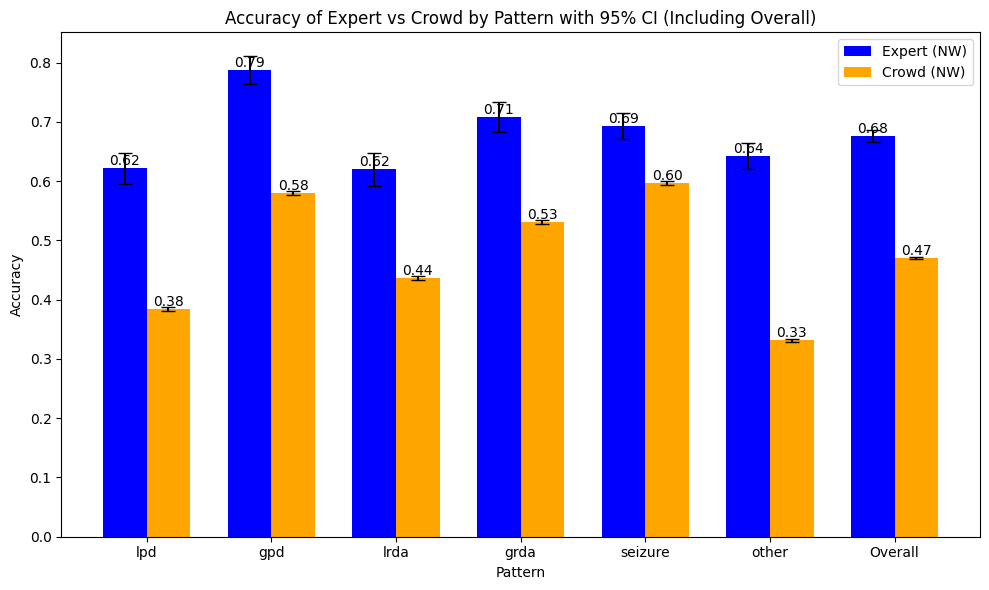

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#df6 from previous
# Separate data for Expert and Non-Expert
df_expert = df6[df6['Group'] == 'Expert']
df_non_expert = df6[df6['Group'] == 'Non-Expert']

# Define x-axis labels (Pattern: LPD, GPD, etc.)
x_labels = list(df_expert['Pattern']) + ['Overall']  # Add 'Overall' to the x-axis labels

# Define the bar positions
x = np.arange(len(x_labels))
width = 0.35

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Expert bars with error bars (including overall)
rects1 = ax.bar(x[:-1] - width/2, df_expert['Accuracy'], width, label='Expert (NW)',
                yerr=[df_expert['Accuracy'] - df_expert['95% CI Lower'], df_expert['95% CI Upper'] - df_expert['Accuracy']],
                capsize=5, color='blue')

# Plot Non-Expert bars with error bars (including overall)
rects2 = ax.bar(x[:-1] + width/2, df_non_expert['Accuracy'], width, label='Crowd (NW)',
                yerr=[df_non_expert['Accuracy'] - df_non_expert['95% CI Lower'], df_non_expert['95% CI Upper'] - df_non_expert['Accuracy']],
                capsize=5, color='orange')

# Add Overall results for Expert and Non-Expert (same color)
rects3 = ax.bar(x[-1] - width/2, overall_results['expert_accuracy'], width,
                yerr=[[overall_results['expert_accuracy'] - overall_results['expert_ci'][0]],
                      [overall_results['expert_ci'][1] - overall_results['expert_accuracy']]],
                capsize=5, color='blue')

rects4 = ax.bar(x[-1] + width/2, overall_results['non_expert_accuracy'], width,
                yerr=[[overall_results['non_expert_accuracy'] - overall_results['non_expert_ci'][0]],
                      [overall_results['non_expert_ci'][1] - overall_results['non_expert_accuracy']]],
                capsize=5, color='orange')

# Add labels and title
ax.set_xlabel('Pattern')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy of Expert vs Crowd by Pattern with 95% CI (Including Overall)')
ax.set_xticks(x)
ax.set_xticklabels(x_labels)

# Update legend
ax.legend(['Expert (NW)', 'Crowd (NW)'])

# Display accuracy values on top of the bars
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width() / 2., height,
            f'{height:.2f}',  # Format the height value to two decimal places
            ha='center', va='bottom'
        )

# Add the values on the Expert, Non-Expert, and Overall bars
add_labels(rects1)
add_labels(rects2)
add_labels(rects3)
add_labels(rects4)

# Show plot
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Step 1: Stratify by expert level
experts = df[df['experience_level'] == 'Expert']
non_experts = df[df['experience_level'] != 'Expert']

def compute_majority_accuracy(data):
    # Step 2: Compute majority vote and correctness
    majority_answer = data.groupby('problem_id').apply(
        lambda x: (x.groupby('title')['combinedaccuracy'].sum()).idxmax()
    )
    correct_answers = data.groupby('problem_id')['goldstandardnew'].first()
    majority_correct = (majority_answer == correct_answers).fillna(False)

    # Step 3: Calculate accuracy and 95% CI
    accuracy = majority_correct.mean()
    n = data['problem_id'].nunique()
    se = np.sqrt(accuracy * (1 - accuracy) / n)
    ci = stats.norm.interval(0.95, loc=accuracy, scale=se)

    return accuracy, ci

# Compute for experts and non-experts
expert_accuracy, expert_ci = compute_majority_accuracy(experts)
non_expert_accuracy, non_expert_ci = compute_majority_accuracy(non_experts)

print(f'Expert Accuracy: {expert_accuracy}, 95% CI: {expert_ci}')
print(f'Non-Expert Accuracy: {non_expert_accuracy}, 95% CI: {non_expert_ci}')

def compute_majority_accuracy(data):
    # Step 2: Compute majority vote and correctness
    majority_answer = data.groupby('problem_id').apply(
        lambda x: (x.groupby('title')['combinedaccuracy'].sum()).idxmax()
    )
    correct_answers = data.groupby('problem_id')['goldstandardnew'].first()
    majority_correct = (majority_answer == correct_answers).fillna(False)

    # Step 3: Calculate accuracy and 95% CI
    accuracy = majority_correct.mean()
    n = data['problem_id'].nunique()  # Total problems evaluated
    correct_n = majority_correct.sum()  # Total problems with majority correct
    se = np.sqrt(accuracy * (1 - accuracy) / n)
    ci = stats.norm.interval(0.95, loc=accuracy, scale=se)

    # Step 4: Return accuracy, CI, total problems, and correct majority problems
    return accuracy, ci, n, correct_n

# Compute for experts and non-experts
expert_accuracy, expert_ci, expert_n, expert_correct_n = compute_majority_accuracy(experts)
non_expert_accuracy, non_expert_ci, non_expert_n, non_expert_correct_n = compute_majority_accuracy(non_experts)

# Step 4: Perform two-proportion z-test to find p-value
# Calculate the pooled proportion
pooled_accuracy = (expert_accuracy * expert_n + non_expert_accuracy * non_expert_n) / (expert_n + non_expert_n)

# Calculate the standard error
se_diff = np.sqrt(pooled_accuracy * (1 - pooled_accuracy) * (1/expert_n + 1/non_expert_n))

# Calculate the z-score
z_score = (expert_accuracy - non_expert_accuracy) / se_diff

# Calculate the p-value
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

print(f'Z-Score: {z_score}')
print(f'P-Value: {p_value}')

<ipython-input-10-86991d8bce57>:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = data.groupby('problem_id').apply(
<ipython-input-10-86991d8bce57>:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = data.groupby('problem_id').apply(


Expert Accuracy: 0.686734693877551, 95% CI: (0.6748794614721207, 0.6985899262829813)
Non-Expert Accuracy: 0.6982235214751518, 95% CI: (0.6886837173172786, 0.7077633256330249)


<ipython-input-10-86991d8bce57>:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = data.groupby('problem_id').apply(


Z-Score: -1.4828087911863705
P-Value: 0.13812521969524028


<ipython-input-10-86991d8bce57>:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = data.groupby('problem_id').apply(


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Create a stratified_experience column (Expert vs Non-Expert)
df['stratified_experience'] = df['experience_level'].apply(lambda x: 'Expert' if x == 'Expert' else 'Non-Expert')

def compute_stratified_majority_accuracy(data):
    """
    For each combination of stratified_experience and goldstandardnew (the pattern),
    compute the majority vote accuracy (using problem_id-level aggregation),
    the 95% confidence interval, number of successes, and sample size.
    """
    results = {}
    # Group by experience and pattern (goldstandardnew)
    grouped = data.groupby(['stratified_experience', 'goldstandardnew'])

    for (level, answer_type), group in grouped:
        # For each problem_id, compute the majority vote based on the sum of combinedaccuracy per title.
        majority_answer = group.groupby('problem_id').apply(
            lambda x: (x.groupby('title')['combinedaccuracy'].sum()).idxmax()
        )
        # Since goldstandardnew should be the same within a problem_id, take the first.
        correct_answers = group.groupby('problem_id')['goldstandardnew'].first()
        majority_correct = (majority_answer == correct_answers).fillna(False)

        # Compute accuracy, successes, and sample size (n)
        accuracy = majority_correct.mean()
        n = len(majority_correct)
        successes = majority_correct.sum()
        se = np.sqrt(accuracy * (1 - accuracy) / n) if n > 0 else np.nan
        ci = stats.norm.interval(0.95, loc=accuracy, scale=se) if n > 0 else (np.nan, np.nan)

        results[(level, answer_type)] = (accuracy, ci, successes, n)
    return results

# Compute accuracy (plus CI, successes, and n) for each (experience, pattern) subgroup
stratified_results = compute_stratified_majority_accuracy(df)

# Print the subgroup results
for (level, answer_type), (accuracy, ci, successes, n) in stratified_results.items():
    print(f'{level} - {answer_type} Accuracy: {accuracy:.3f}, 95% CI: {ci}, n: {n}')

# --- Compute p-values comparing Expert vs Non-Expert for each pattern ---
# We'll compare the accuracy (proportion of correct majority votes) for each pattern.
p_values = {}
# Extract unique patterns from the keys (which come from goldstandardnew)
patterns = set([key[1] for key in stratified_results.keys()])

for pattern in patterns:
    key_expert = ('Expert', pattern)
    key_non_expert = ('Non-Expert', pattern)
    if key_expert in stratified_results and key_non_expert in stratified_results:
        accuracy_e, ci_e, successes_e, n_e = stratified_results[key_expert]
        accuracy_ne, ci_ne, successes_ne, n_ne = stratified_results[key_non_expert]

        # Pooled proportion for the two groups
        pooled = (successes_e + successes_ne) / (n_e + n_ne)
        # Standard error for the difference in proportions
        se_diff = np.sqrt(pooled * (1 - pooled) * (1/n_e + 1/n_ne))
        # z-score for difference in proportions
        z = (accuracy_e - accuracy_ne) / se_diff
        # Two-tailed p-value
        p_val = 2 * (1 - stats.norm.cdf(abs(z)))
        p_values[pattern] = p_val
        print(f'Pattern: {pattern} - p-value comparing Expert vs Non-Expert: {p_val:.4f}')


<ipython-input-11-bebb16ffecd6>:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = group.groupby('problem_id').apply(
<ipython-input-11-bebb16ffecd6>:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = group.groupby('problem_id').apply(
<ipython-input-11-bebb16ffecd6>:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated

Expert - gpd Accuracy: 0.790, 95% CI: (0.7628127875130045, 0.8180255358402889), n: 835
Expert - grda Accuracy: 0.723, 95% CI: (0.6925463317735591, 0.753795131641075), n: 820
Expert - lpd Accuracy: 0.634, 95% CI: (0.6031553374929172, 0.6639254078486977), n: 966
Expert - lrda Accuracy: 0.643, 95% CI: (0.6058538068114654, 0.6794222668081664), n: 652
Expert - other Accuracy: 0.641, 95% CI: (0.614760937866724, 0.6667035930257246), n: 1311
Expert - seizure Accuracy: 0.705, 95% CI: (0.6804244222294596, 0.7300694049310342), n: 1296
Non-Expert - gpd Accuracy: 0.861, 95% CI: (0.8432887553443748, 0.8792464559232308), n: 1420
Non-Expert - grda Accuracy: 0.870, 95% CI: (0.8508353336236998, 0.8882951011589089), n: 1242
Non-Expert - lpd Accuracy: 0.596, 95% CI: (0.5708867015117316, 0.6203773620223518), n: 1511
Non-Expert - lrda Accuracy: 0.730, 95% CI: (0.701023705426129, 0.7594729085693563), n: 886
Non-Expert - other Accuracy: 0.468, 95% CI: (0.44588164389727747, 0.4902666568236288), n: 1942
Non-Exp

<ipython-input-11-bebb16ffecd6>:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = group.groupby('problem_id').apply(


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

df['stratified_experience'] = df['experience_level'].apply(lambda x: 'Expert' if x == 'Expert' else 'Non-Expert')

def compute_stratified_majority_accuracy(data):
    # Initialize a dictionary to store accuracy and CI for each subgroup
    results = {}

    # Step 1: Group by answer type within each experience level group
    grouped = data.groupby(['stratified_experience', 'goldstandardnew'])

    for (level, answer_type), group in grouped:
        # Step 2: Compute majority vote and correctness within each subgroup
        majority_answer = group.groupby('problem_id').apply(
            lambda x: (x.groupby('title')['combinedaccuracy'].sum()).idxmax()
        )
        correct_answers = group.groupby('problem_id')['goldstandardnew'].first()  # Get the first as all should be the same for each problem_id
        majority_correct = (majority_answer == correct_answers).fillna(False)

        # Step 3: Calculate accuracy and 95% CI for each subgroup
        accuracy = majority_correct.mean()
        n = len(majority_correct)
        se = np.sqrt(accuracy * (1 - accuracy) / n)
        ci = stats.norm.interval(0.95, loc=accuracy, scale=se)

        # Store the results
        results[(level, answer_type)] = (accuracy, ci)

    return results

# Compute accuracy and CI stratified by experience level and answer type
stratified_results = compute_stratified_majority_accuracy(df)

# Print results
for (level, answer_type), (accuracy, ci) in stratified_results.items():
    print(f'{level} - {answer_type} Accuracy: {accuracy}, 95% CI: {ci}')

<ipython-input-12-cbd9ae717f49>:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = group.groupby('problem_id').apply(
<ipython-input-12-cbd9ae717f49>:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = group.groupby('problem_id').apply(
<ipython-input-12-cbd9ae717f49>:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated

Expert - gpd Accuracy: 0.7904191616766467, 95% CI: (0.7628127875130045, 0.8180255358402889)
Expert - grda Accuracy: 0.723170731707317, 95% CI: (0.6925463317735591, 0.753795131641075)
Expert - lpd Accuracy: 0.6335403726708074, 95% CI: (0.6031553374929172, 0.6639254078486977)
Expert - lrda Accuracy: 0.6426380368098159, 95% CI: (0.6058538068114654, 0.6794222668081664)
Expert - other Accuracy: 0.6407322654462243, 95% CI: (0.614760937866724, 0.6667035930257246)
Expert - seizure Accuracy: 0.7052469135802469, 95% CI: (0.6804244222294596, 0.7300694049310342)
Non-Expert - gpd Accuracy: 0.8612676056338028, 95% CI: (0.8432887553443748, 0.8792464559232308)
Non-Expert - grda Accuracy: 0.8695652173913043, 95% CI: (0.8508353336236998, 0.8882951011589089)
Non-Expert - lpd Accuracy: 0.5956320317670417, 95% CI: (0.5708867015117316, 0.6203773620223518)
Non-Expert - lrda Accuracy: 0.7302483069977427, 95% CI: (0.701023705426129, 0.7594729085693563)
Non-Expert - other Accuracy: 0.46807415036045313, 95% CI: 

<ipython-input-12-cbd9ae717f49>:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = group.groupby('problem_id').apply(


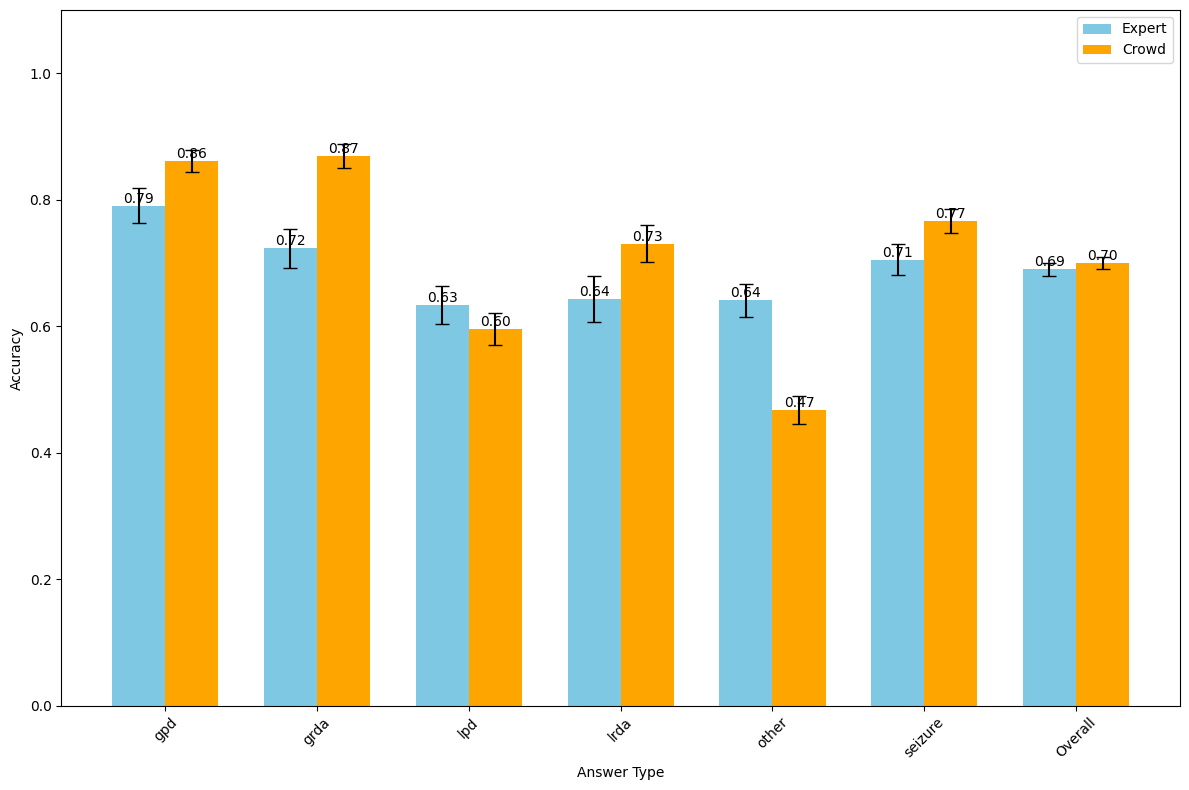

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract unique levels and answer types from the results
levels = sorted(set(level for level, _ in stratified_results.keys()))
answer_types = sorted(set(answer_type for _, answer_type in stratified_results.keys()))

# Initialize data for plotting
accuracy_data = {level: [] for level in levels}
ci_lower_data = {level: [] for level in levels}
ci_upper_data = {level: [] for level in levels}

# Populate the data structures
for answer_type in answer_types:
    for level in levels:
        accuracy, ci = stratified_results.get((level, answer_type), (0, (0, 0)))  # Default to 0 if no data
        accuracy_data[level].append(accuracy)
        ci_lower_data[level].append(accuracy - ci[0])
        ci_upper_data[level].append(ci[1] - accuracy)

# Additional data for expert and crowd to combine chart
additional_levels = ['Expert', 'Crowd']
additional_accuracies = [0.69, 0.7]
additional_ci_lowers = [0.69 - 0.68, 0.7 - 0.69]
additional_ci_uppers = [0.7 - 0.69, 0.71 - 0.7]

# Define colors that match the original chart's color scheme
colors = {'Expert': '#7EC8E3', 'Crowd': 'orange', 'Non-Expert': 'orange'}

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))
bar_width = 0.35
index = np.arange(len(answer_types) + 1)  # Add an extra index for the additional group

# Plot existing accuracy data with the same colors
for i, level in enumerate(levels):
    bars = ax.bar(index[:-1] + i * bar_width, accuracy_data[level], bar_width,
                  yerr=[ci_lower_data[level], ci_upper_data[level]],
                  capsize=5, label=level if i == 0 else "", color=colors.get(level, 'grey'))  # Label only the first instance

# Plot additional accuracy data for expert and crowd with specified colors
for i, level in enumerate(additional_levels):
    ax.bar(index[-1] + i * bar_width, additional_accuracies[i], bar_width,
           yerr=[[additional_ci_lowers[i]], [additional_ci_uppers[i]]],
           capsize=5, label=level if level not in levels else "", color=colors[level])

# Add labels and legend
ax.set_xlabel('Answer Type')
ax.set_ylabel('Accuracy')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(answer_types + ['Overall'])  # Add a label for the additional group

# Combine legend entries
handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))  # Remove duplicates by converting to a dictionary
ax.legend(unique_labels.values(), unique_labels.keys())

# Add annotations for accuracy values
for i, level in enumerate(levels):
    for j, answer_type in enumerate(answer_types):
        ax.text(j + i * bar_width, accuracy_data[level][j],
                f'{accuracy_data[level][j]:.2f}', ha='center', va='bottom')

# Add annotations for expert and crowd
for i, (accuracy, ci_lower, ci_upper) in enumerate(zip(additional_accuracies, additional_ci_lowers, additional_ci_uppers)):
    ax.text(len(answer_types) + i * bar_width, accuracy,
            f'{accuracy:.2f}', ha='center', va='bottom')

plt.xticks(rotation=45)  # Rotate answer type labels for better readability
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()


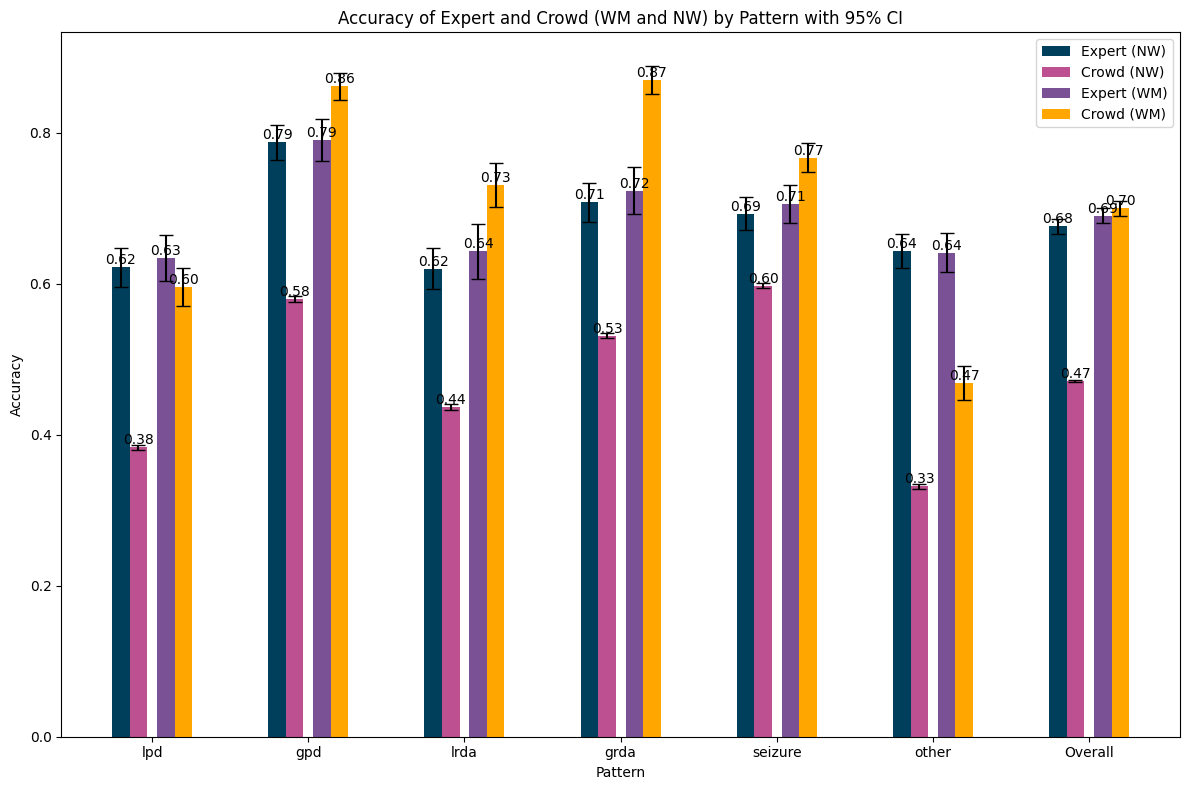

In [ ]:
#combing both plots
import matplotlib.pyplot as plt
import numpy as np

# Define x-axis labels (Patterns: LPD, GPD, etc.)
x_labels = list(df_expert['Pattern']) + ['Overall']  # Add 'Overall' to the x-axis labels

# Bar width and positions
spacing_factor = 0.6  # Adjust this value for more spacing between patterns
x = np.arange(len(x_labels)) * (1 + spacing_factor)  # Adjust x positions with spacing
width = 0.18  # the width of the bars
gap = 0.05  # gap between NW and WM groups

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Ensure correct order of patterns between df_expert and stratified_results
patterns = df_expert['Pattern'].tolist()

# Define more muted (matt) colors
colors = {
    'Expert (NW)': '#003f5c',  # Dark blue
    'Crowd (NW)': '#bc5090',  # Dark orange (muted)
    'Expert (WM)': '#7a5195',  # Light blue (muted)
    'Crowd (WM)': '#ffa600'    # Light orange (muted)
}

# Plot Expert (NW) bars with error bars (including overall)
expert_nw_accuracies = df_expert['Accuracy'].tolist() + [overall_results['expert_accuracy']]  # Append overall accuracy
expert_nw_ci_lowers = (df_expert['Accuracy'] - df_expert['95% CI Lower']).tolist() + [overall_results['expert_accuracy'] - overall_results['expert_ci'][0]]
expert_nw_ci_uppers = (df_expert['95% CI Upper'] - df_expert['Accuracy']).tolist() + [overall_results['expert_ci'][1] - overall_results['expert_accuracy']]

rects1 = ax.bar(x - (1.5 * width + gap), expert_nw_accuracies, width, label='Expert (NW)',
                yerr=[expert_nw_ci_lowers, expert_nw_ci_uppers], capsize=5, color=colors['Expert (NW)'])

# Plot Crowd (NW) bars with error bars (including overall)
crowd_nw_accuracies = df_non_expert['Accuracy'].tolist() + [overall_results['non_expert_accuracy']]
crowd_nw_ci_lowers = (df_non_expert['Accuracy'] - df_non_expert['95% CI Lower']).tolist() + [overall_results['non_expert_accuracy'] - overall_results['non_expert_ci'][0]]
crowd_nw_ci_uppers = (df_non_expert['95% CI Upper'] - df_non_expert['Accuracy']).tolist() + [overall_results['non_expert_ci'][1] - overall_results['non_expert_accuracy']]

rects2 = ax.bar(x - (0.5 * width + gap), crowd_nw_accuracies, width, label='Crowd (NW)',
                yerr=[crowd_nw_ci_lowers, crowd_nw_ci_uppers], capsize=5, color=colors['Crowd (NW)'])

# Plot Expert (WM) bars with error bars based on the order of df_expert patterns (including overall)
expert_wm_accuracies = [stratified_results.get(('Expert', pattern), (0, (0, 0)))[0] for pattern in patterns] + [0.69]  # Append overall WM accuracy
expert_wm_ci_lowers = [(stratified_results.get(('Expert', pattern), (0, (0, 0)))[0] - stratified_results.get(('Expert', pattern), (0, (0, 0)))[1][0]) for pattern in patterns] + [0.69 - 0.68]
expert_wm_ci_uppers = [(stratified_results.get(('Expert', pattern), (0, (0, 0)))[1][1] - stratified_results.get(('Expert', pattern), (0, (0, 0)))[0]) for pattern in patterns] + [0.7 - 0.69]

rects3 = ax.bar(x + (0.5 * width + gap), expert_wm_accuracies, width, label='Expert (WM)',
                yerr=[expert_wm_ci_lowers, expert_wm_ci_uppers], capsize=5, color=colors['Expert (WM)'])

# Plot Crowd (WM) bars with error bars based on the order of df_expert patterns (including overall)
crowd_wm_accuracies = [stratified_results.get(('Non-Expert', pattern), (0, (0, 0)))[0] for pattern in patterns] + [0.7]  # Append overall WM accuracy
crowd_wm_ci_lowers = [(stratified_results.get(('Non-Expert', pattern), (0, (0, 0)))[0] - stratified_results.get(('Non-Expert', pattern), (0, (0, 0)))[1][0]) for pattern in patterns] + [0.7 - 0.69]
crowd_wm_ci_uppers = [(stratified_results.get(('Non-Expert', pattern), (0, (0, 0)))[1][1] - stratified_results.get(('Non-Expert', pattern), (0, (0, 0)))[0]) for pattern in patterns] + [0.71 - 0.7]

rects4 = ax.bar(x + (1.5 * width + gap), crowd_wm_accuracies, width, label='Crowd (WM)',
                yerr=[crowd_wm_ci_lowers, crowd_wm_ci_uppers], capsize=5, color=colors['Crowd (WM)'])

# Add labels and title
ax.set_xlabel('Pattern')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy of Expert and Crowd (WM and NW) by Pattern with 95% CI')
ax.set_xticks(x)
ax.set_xticklabels(x_labels)

# Update legend
ax.legend(['Expert (NW)', 'Crowd (NW)', 'Expert (WM)', 'Crowd (WM)'])

# Display accuracy values on top of the bars
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width() / 2., height,
            f'{height:.2f}',
            ha='center', va='bottom'
        )

# Add the values on top of all the bars
add_labels(rects1)
add_labels(rects2)
add_labels(rects3)
add_labels(rects4)

# Show plot
plt.tight_layout()
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Figure 3 (long time to process, especially if bootstrap to 1000)

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import random
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm

# Assuming df is your DataFrame
# Step 1: Stratify by expert level
experts = df[df['experience_level'] == 'Expert']
non_experts = df[df['experience_level'] != 'Expert']

def compute_majority_accuracy(data):
    # Step 2: Compute majority vote and correctness
    majority_answer = data.groupby('problem_id').apply(
        lambda x: (x.groupby('title')['combinedaccuracy'].sum()).idxmax()
    )
    correct_answers = data.groupby('problem_id')['goldstandardnew'].first()
    majority_correct = (majority_answer == correct_answers).fillna(False)

    # Step 3: Calculate accuracy and 95% CI
    accuracy = majority_correct.mean()
    n = data['problem_id'].nunique()  # Total problems evaluated
    se = np.sqrt(accuracy * (1 - accuracy) / n)
    ci = stats.norm.interval(0.95, loc=accuracy, scale=se)

    return accuracy, ci

# Compute for experts
expert_accuracy, expert_ci = compute_majority_accuracy(experts)

# Step 2: Sensitivity analysis for non-experts
def bootstrap_majority_accuracy(data, sample_size, n_bootstrap=10):
    problem_ids = data['problem_id'].unique()
    bootstrapped_accuracies = []

    def bootstrap_iteration(_):
        sampled_data_list = []

        for pid in problem_ids:
            filtered_data = data[data['problem_id'] == pid]
            if filtered_data['user_id'].nunique() > sample_size:
                sampled_users = random.sample(list(filtered_data['user_id'].unique()), sample_size)
                sampled_data_list.append(filtered_data[filtered_data['user_id'].isin(sampled_users)])

        if sampled_data_list:
            sampled_data = pd.concat(sampled_data_list)
            accuracy, _ = compute_majority_accuracy(sampled_data)
            return accuracy
        return None

    bootstrapped_accuracies = Parallel(n_jobs=-1)(delayed(bootstrap_iteration)(_) for _ in tqdm(range(n_bootstrap), desc="Bootstrapping"))

    # Filter out None values if any
    bootstrapped_accuracies = [acc for acc in bootstrapped_accuracies if acc is not None]

    # Calculate the average accuracy over the bootstrap samples
    avg_bootstrap_accuracy = np.mean(bootstrapped_accuracies)

    # Calculate the 95% confidence interval using percentiles
    lower_bound = np.percentile(bootstrapped_accuracies, 2.5)
    upper_bound = np.percentile(bootstrapped_accuracies, 97.5)
    ci_bootstrap = (lower_bound, upper_bound)

    return avg_bootstrap_accuracy, ci_bootstrap

# Sample sizes to evaluate
sample_sizes = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

# Store results for plotting
non_expert_accuracies = []
non_expert_cis = []

for sample_size in tqdm(sample_sizes, desc="Processing Sample Sizes"):
    non_expert_accuracy, non_expert_ci = bootstrap_majority_accuracy(non_experts, sample_size, n_bootstrap=10)
    non_expert_accuracies.append(non_expert_accuracy)
    non_expert_cis.append(non_expert_ci)

# Visualization
plt.figure(figsize=(12, 8))

# Plot expert accuracy (horizontal line)
plt.axhline(y=expert_accuracy, color='blue', linestyle='-', label='Expert Accuracy')
plt.text(x=sample_sizes[-1] + 2, y=expert_accuracy,
         s=f'{expert_accuracy:.2f}\n[{expert_ci[0]:.2f}, {expert_ci[1]:.2f}]',
         color='blue', va='center')

# Plot non-expert accuracies with error bars
lower_errors = [acc - ci[0] for acc, ci in zip(non_expert_accuracies, non_expert_cis)]
upper_errors = [ci[1] - acc for acc, ci in zip(non_expert_accuracies, non_expert_cis)]
yerr = [lower_errors, upper_errors]

plt.errorbar(sample_sizes, non_expert_accuracies,
             yerr=yerr, fmt='o-', color='green', capsize=5, label='Non-Expert Bootstrapped Accuracy')

# Annotate non-expert points
for i, (x, y, ci) in enumerate(zip(sample_sizes, non_expert_accuracies, non_expert_cis)):
    plt.text(x, y, f'{y:.2f}\n[{ci[0]:.2f}, {ci[1]:.2f}]', ha='center', va='bottom', color='green')

plt.ylim(0, 1)  # Start y-axis at 0
plt.xlabel('Sample Size (Number of User Responses)')
plt.ylabel('Accuracy')
plt.title('Expert vs Non-Expert (Bootstrapped) Accuracy across Different Sample Sizes')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


<ipython-input-15-0534ee322a6e>:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = data.groupby('problem_id').apply(
Processing Sample Sizes:   0%|          | 0/10 [00:12<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
supplemental s2

In [ ]:
# for each pattern
import pandas as pd
from itertools import combinations

def analyze_user_pairs3(df):
    # Drop rows with NaN values in columns B, C, D, or E
    clean_df = df.dropna(subset=['user_id', 'problem_id', 'title','goldstandardnew','experience_level'])

    # Step 1: Select unique pairs of users from column B
    unique_users = clean_df['user_id'].unique()
    user_pairs = list(combinations(unique_users, 2))  # Create all possible unique pairs

    # Patterns to be checked
    patterns = ['lpd', 'gpd', 'lrda', 'grda', 'seizure', 'other']

    # Prepare the new DataFrame to store the results
    results_list = []

    for pair in user_pairs:
        user_a, user_b = pair

        for pattern in patterns:
            # Initialize the results for this pair and pattern
            results_dict = {'User Pair': f'{user_a} vs {user_b}', 'Pattern': pattern}

            # Filter the rows for each user and pattern
            user_a_data = clean_df[(clean_df['user_id'] == user_a) & (clean_df['goldstandardnew'] == pattern)]
            user_b_data = clean_df[(clean_df['user_id'] == user_b) & (clean_df['goldstandardnew'] == pattern)]

            # Find the common problem IDs (overlap) for the current pattern
            common_problems = set(user_a_data['problem_id']).intersection(set(user_b_data['problem_id']))
            total_overlaps = len(common_problems)
            correct_overlaps = 0

            # Check for correct answers
            for problem_id in common_problems:
                user_a_answer = user_a_data[user_a_data['problem_id'] == problem_id]['title'].iloc[0]
                user_b_answer = user_b_data[user_b_data['problem_id'] == problem_id]['title'].iloc[0]
                if user_a_answer == pattern and user_b_answer == pattern:
                    correct_overlaps += 1

            # Fill the results for this user pair and pattern
            results_dict['Total Overlaps'] = total_overlaps
            results_dict['Correct Overlaps'] = correct_overlaps
            results_dict['Accuracy'] = correct_overlaps / total_overlaps if total_overlaps > 0 else 0

            # Append the results to the results list
            results_list.append(results_dict)

    # Convert the results list to a DataFrame
    results_df = pd.DataFrame(results_list)
    return results_df

df2=df[df['experience_level'] == 'Expert']
df4=analyze_user_pairs3(df2)
df4 = df4[(df4['Total Overlaps'] != 0)]

   Pattern  Mean_Accuracy        SE  Min_Accuracy  Max_Accuracy  Total_Pairs  \
0      gpd       0.601484  0.034587      0.375000      0.786885           14   
1     grda       0.477024  0.052499      0.000000      0.681159           14   
2      lpd       0.413237  0.030809      0.187500      0.666667           14   
3     lrda       0.439017  0.033034      0.157895      0.636364           15   
4    other       0.570168  0.025102      0.473684      0.833333           16   
5  seizure       0.504564  0.018368      0.384615      0.636364           14   

   CI_Lower  CI_Upper  
0  0.533695  0.669272  
1  0.374128  0.579920  
2  0.352854  0.473621  
3  0.374272  0.503761  
4  0.520968  0.619367  
5  0.468563  0.540564  


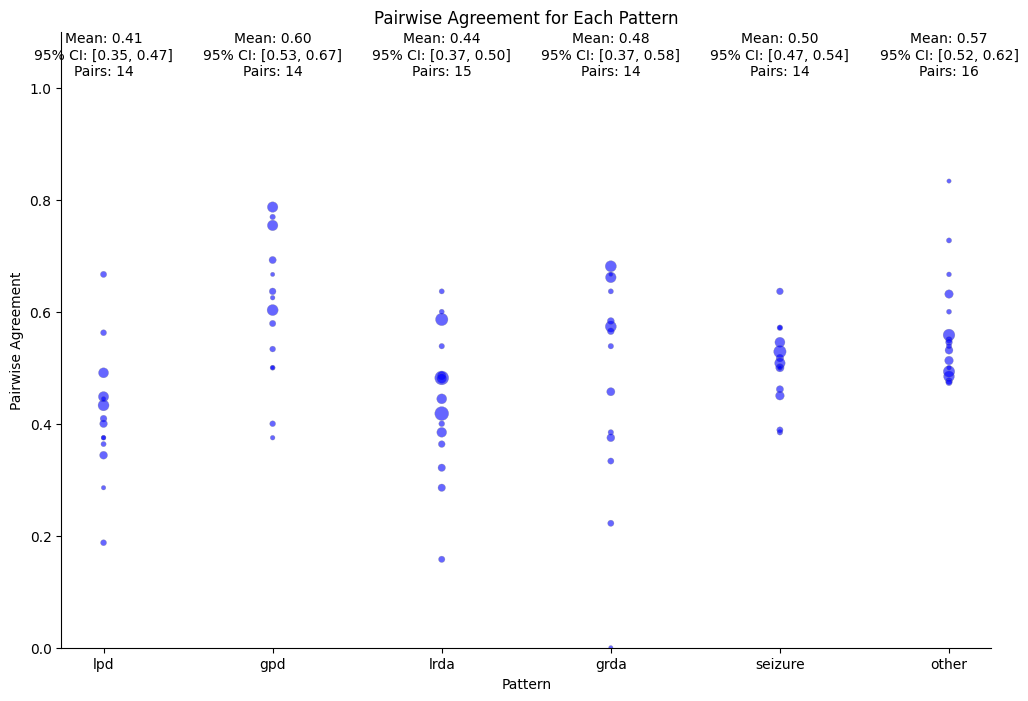

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

def calculate_statistics_by_pattern(results_df):
    # Filter to include only user pairs with more than 5 total overlaps
    filtered_df = results_df[results_df['Total Overlaps'] > 5]

    # Group by Pattern to calculate mean accuracy, standard error, confidence intervals, and total user pairs
    pattern_stats_df = filtered_df.groupby('Pattern').agg(
        Mean_Accuracy=('Accuracy', 'mean'),
        SE=('Accuracy', stats.sem),
        Min_Accuracy=('Accuracy', 'min'),
        Max_Accuracy=('Accuracy', 'max'),
        Total_Pairs=('User Pair', 'size')
    ).reset_index()

    # Calculate the 95% confidence interval for each pattern's mean accuracy
    pattern_stats_df['CI_Lower'], pattern_stats_df['CI_Upper'] = stats.norm.interval(
        0.95, loc=pattern_stats_df['Mean_Accuracy'], scale=pattern_stats_df['SE']
    )

    # Ensure CI bounds are within valid limits [0, 1]
    pattern_stats_df['CI_Lower'] = pattern_stats_df['CI_Lower'].clip(lower=0)
    pattern_stats_df['CI_Upper'] = pattern_stats_df['CI_Upper'].clip(upper=1)

    return pattern_stats_df, filtered_df

# Calculate statistics by pattern
pattern_stats_df, filtered_df = calculate_statistics_by_pattern(df4)

# Print the statistics for each pattern
print(pattern_stats_df)

# Plotting the scatter plot
plt.figure(figsize=(12, 8))

# Adding dots for each user pair with size representing Total Overlaps
sns.scatterplot(x='Pattern', y='Accuracy', data=filtered_df, size=filtered_df['Total Overlaps'],
                sizes=(10, 100), legend=False, color='blue', edgecolor="gray", alpha=0.6)

# Annotating the mean accuracy, 95% CI, and total number of user pairs for each pattern
for i, row in pattern_stats_df.iterrows():
    plt.text(x=row['Pattern'], y=1.1,  # Adjusted y-coordinate for lower position
             s=f"Mean: {row['Mean_Accuracy']:.2f}\n95% CI: [{row['CI_Lower']:.2f}, {row['CI_Upper']:.2f}]\nPairs: {row['Total_Pairs']}",
             ha='center', va='top', fontsize=10, color='black')

# Customizing the plot
plt.title('Pairwise Agreement for Each Pattern')
plt.ylabel('Pairwise Agreement')
plt.xlabel('Pattern')
plt.ylim(0, 1.1)  # Adjust y-axis to provide space for CI annotations
plt.grid(False)   # Remove the grid

# Remove upper and left borders
sns.despine(right=True, top=True)

# Show the plot
plt.show()


Supplemental S3

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

def compute_accuracy_per_user(data):
    # Initialize a dictionary to store accuracy, CI, SE, and n for each user
    user_results = {}

    # Group data by user_id
    user_groups = data.groupby('user_id')

    for user_id, group in user_groups:
        # Calculate the correctness of each answer for the user
        correct_answers = (group['title'] == group['goldstandardnew'])

        # Calculate accuracy for each user
        accuracy = correct_answers.mean()
        n = group['problem_id'].nunique()  # Number of unique problem IDs answered by the user
        se = np.sqrt(accuracy * (1 - accuracy) / n)

        # Compute confidence interval and adjust bounds
        ci_low, ci_high = stats.norm.interval(0.95, loc=accuracy, scale=se)
        ci_low = max(0, ci_low)  # Lower bound should not be less than 0
        ci_high = min(1, ci_high)  # Upper bound should not exceed 1

        ci = (ci_low, ci_high)

        # Store the results, including SE and n
        user_results[user_id] = (accuracy, ci, se, n)

    return user_results

# Compute accuracy, CI, SE, and n for each expert
expert_accuracies = compute_accuracy_per_user(experts)

# Print results for each expert
for user_id, (accuracy, ci, se, n) in expert_accuracies.items():
    print(f'User ID: {user_id} - Accuracy: {accuracy:.4f}, 95% CI: [{ci[0]:.4f}, {ci[1]:.4f}], SE: {se:.4f}, Number of Problems: {n}')


User ID: 41816 - Accuracy: 0.6710, 95% CI: [0.6424, 0.6996], SE: 0.0146, Number of Problems: 1036
User ID: 123180 - Accuracy: 0.7026, 95% CI: [0.6887, 0.7164], SE: 0.0071, Number of Problems: 4187
User ID: 129198 - Accuracy: 0.6410, 95% CI: [0.6116, 0.6703], SE: 0.0150, Number of Problems: 1025
User ID: 129968 - Accuracy: 0.5851, 95% CI: [0.5411, 0.6290], SE: 0.0224, Number of Problems: 482
User ID: 129995 - Accuracy: 0.6444, 95% CI: [0.5046, 0.7843], SE: 0.0714, Number of Problems: 45
User ID: 130067 - Accuracy: 0.6093, 95% CI: [0.5571, 0.6616], SE: 0.0267, Number of Problems: 335
User ID: 130226 - Accuracy: 0.6670, 95% CI: [0.6362, 0.6979], SE: 0.0157, Number of Problems: 898
User ID: 130262 - Accuracy: 0.6667, 95% CI: [0.5373, 0.7960], SE: 0.0660, Number of Problems: 51


In [ ]:
import numpy as np
from scipy import stats

def calculate_accuracy_difference_and_p_value(expert_accuracies, crowd_accuracy, crowd_se, crowd_n):
    results = {}

    for user_id, values in expert_accuracies.items():
        # Unpack only the accuracy, SE, and n, skipping the CI
        user_accuracy, _, user_se, n = values

        # Calculate the accuracy difference
        accuracy_diff = user_accuracy - crowd_accuracy

        # Calculate the combined standard error for the difference
        se_diff = np.sqrt(user_se**2 + crowd_se**2)

        # Calculate the Z-score
        z_score = accuracy_diff / se_diff

        # Calculate the p-value
        p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

        # Store the results
        results[user_id] = (accuracy_diff, z_score, p_value)

    return results

# Calculate the crowd standard error
crowd_se = np.sqrt(non_expert_accuracy * (1 - non_expert_accuracy) / non_expert_n)

# Compute the accuracy difference and p-value for each expert
accuracy_diff_results = calculate_accuracy_difference_and_p_value(expert_accuracies, non_expert_accuracy, crowd_se, non_expert_n)

# Print the results
for user_id, (accuracy_diff, z_score, p_value) in accuracy_diff_results.items():
    print(f'User ID: {user_id} - Accuracy Difference: {accuracy_diff:.4f}, Z-Score: {z_score:.4f}, P-Value: {p_value:.4f}')


User ID: 41816 - Accuracy Difference: -0.0272, Z-Score: -1.7702, P-Value: 0.0767
User ID: 123180 - Accuracy Difference: 0.0043, Z-Score: 0.5043, P-Value: 0.6140
User ID: 129198 - Accuracy Difference: -0.0572, Z-Score: -3.6338, P-Value: 0.0003
User ID: 129968 - Accuracy Difference: -0.1132, Z-Score: -4.9277, P-Value: 0.0000
User ID: 129995 - Accuracy Difference: -0.0538, Z-Score: -0.7519, P-Value: 0.4521
User ID: 130067 - Accuracy Difference: -0.0889, Z-Score: -3.2805, P-Value: 0.0010
User ID: 130226 - Accuracy Difference: -0.0312, Z-Score: -1.8943, P-Value: 0.0582
User ID: 130262 - Accuracy Difference: -0.0316, Z-Score: -0.4768, P-Value: 0.6335


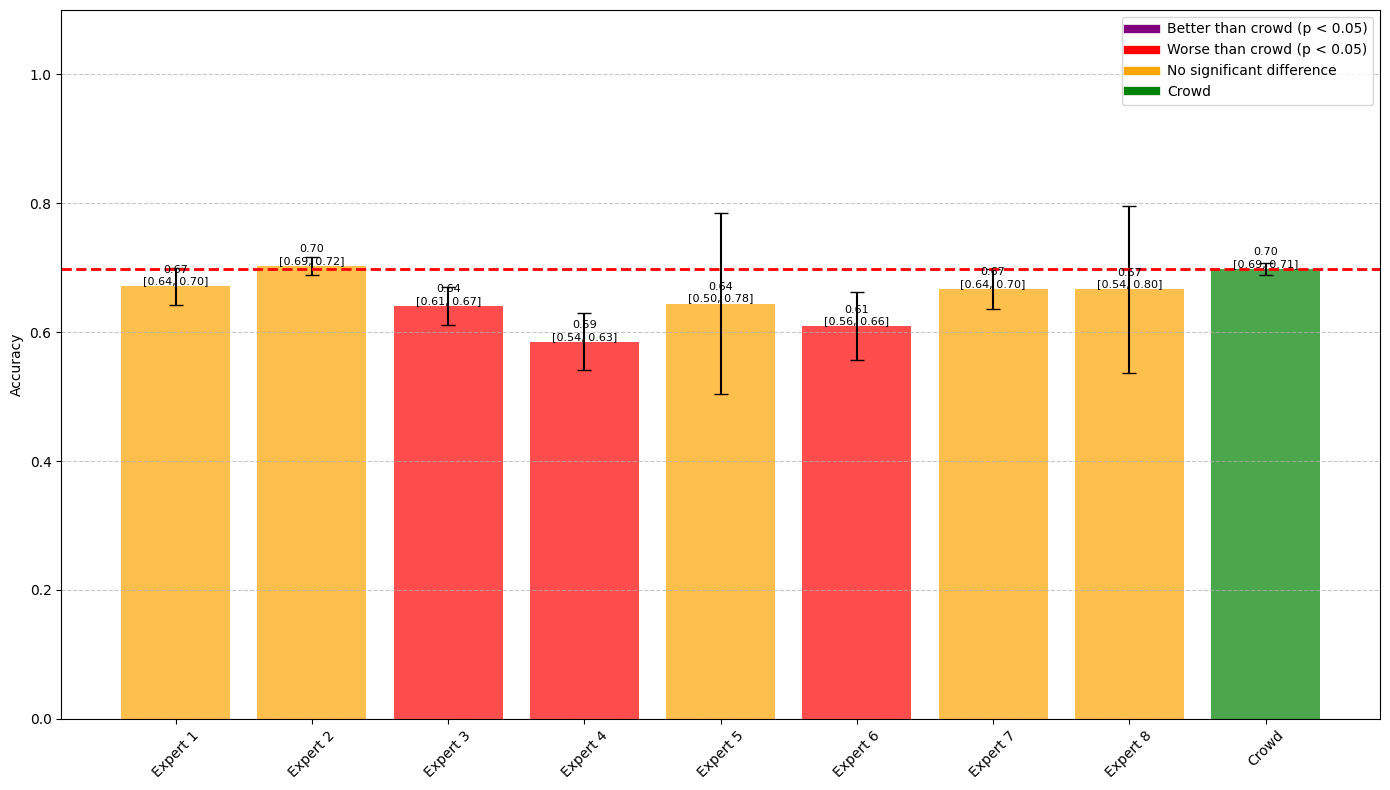

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract non-expert (crowd) accuracies for each answer type from stratified_results
non_expert_accuracies = {atype: results for (level, atype), results in stratified_results.items() if level == 'Non-Expert'}

# Prepare plotting data
user_ids = [f'Expert {i+1}' for i in range(len(expert_accuracies))] + ['Crowd']  # Label experts as "Expert 1", "Expert 2", etc.
# Collect expert accuracies and append the crowd's accuracy at the end
accuracies = [expert_accuracies[user_id][0] for user_id in expert_accuracies] + [non_expert_accuracy]

# Combine the experts' CI ranges and append the crowd's CI range at the end
ci_ranges = [(max(0, accuracy - ci_low), max(0, ci_high - accuracy)) for accuracy, (ci_low, ci_high), _, _ in expert_accuracies.values()]
ci_ranges.append((max(0, non_expert_accuracy - non_expert_ci[0]), max(0, non_expert_ci[1] - non_expert_accuracy)))

# Extract separate lists for lower and upper error values
lower_errors, upper_errors = zip(*ci_ranges)

# Determine bar colors based on accuracy difference and p-value
colors = []
for user_id in expert_accuracies:
    accuracy_diff, z_score, p_value = accuracy_diff_results[user_id]
    if p_value < 0.05:
        if accuracy_diff < 0:
            colors.append('red')  # Negative difference, significant
        else:
            colors.append('purple')  # Positive difference, significant
    else:
        colors.append('orange')  # Not significant
colors.append('green')  # Color for 'Crowd'

# Creating the plot
plt.figure(figsize=(14, 8))  # Adjust the figure size as necessary

# Create numeric values for x-axis positions
x_values = range(len(user_ids))

# Plot the bars with error bars for both experts and the crowd
bars = plt.bar(x_values, accuracies, yerr=[lower_errors, upper_errors], capsize=5, alpha=0.7, color=colors)

# Set the x-ticks to correspond to user_ids
plt.xticks(x_values, user_ids, rotation=45)

# Adding text annotations for accuracy and CI for each expert and the crowd
for bar, accuracy, (lower, upper) in zip(bars, accuracies, ci_ranges):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height(),
             f'{accuracy:.2f}\n[{accuracy - lower:.2f}, {accuracy + upper:.2f}]',
             ha='center', va='bottom', fontsize=8)

crowd_accuracy = non_expert_accuracy
plt.axhline(y=crowd_accuracy, color='red', linestyle='--', linewidth=2, label=f'Non-Expert Accuracy ({crowd_accuracy:.2f})')

# Set chart labels
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)  # Adjust the y-axis limit to make room for annotations
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Custom legend
legend_handles = [
    plt.Line2D([0], [0], color='purple', lw=6, label='Better than crowd (p < 0.05)'),
    plt.Line2D([0], [0], color='red', lw=6, label='Worse than crowd (p < 0.05)'),
    plt.Line2D([0], [0], color='orange', lw=6, label='No significant difference'),
    plt.Line2D([0], [0], color='green', lw=6, label='Crowd'),
]
plt.legend(handles=legend_handles)

plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels

plt.show()


In [ ]:
Supplemental S4

SyntaxError: invalid syntax (<ipython-input-22-b8f76488e2ef>, line 1)

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

df['stratified_experience'] = df['experience_level'].apply(lambda x: 'Expert' if x == 'Expert' else 'Non-Expert')

def compute_accuracy_per_user_and_answer_type(data):
    # Ensure data only contains experts
    expert_data = data[data['stratified_experience'] == 'Expert']

    # Initialize a dictionary to store accuracy, SE, and n for each user and answer type
    results = {}

    # Group by user ID and answer type
    grouped = expert_data.groupby(['user_id', 'goldstandardnew'])

    for (user_id, answer_type), group in grouped:
        # Skip groups with missing user_id or goldstandardnew
        if pd.isnull(user_id) or pd.isnull(answer_type):
            continue  # Skip to the next group

        # Calculate the correctness of each answer for the user
        correct_answers = (group['title'] == group['goldstandardnew'])

        # Calculate accuracy for each user and answer type
        accuracy = correct_answers.mean()
        n = group['problem_id'].nunique()  # Number of unique problem IDs answered by the user
        se = np.sqrt(accuracy * (1 - accuracy) / n)

        # Compute confidence interval and adjust bounds
        ci_low, ci_high = stats.norm.interval(0.95, loc=accuracy, scale=se)
        ci_low = max(0, ci_low)  # Lower bound should not be less than 0
        ci_high = min(1, ci_high)  # Upper bound should not exceed 1

        ci = (ci_low, ci_high)

        # Store the results, including SE and n
        results[(user_id, answer_type)] = (accuracy, ci, se, n)

    return results

# Compute accuracy, CI, SE, and n for each answer type and user ID for experts
expert_stratified_results = compute_accuracy_per_user_and_answer_type(df)

# Print results
for (user_id, answer_type), (accuracy, ci, se, n) in expert_stratified_results.items():
    print(f'User ID: {user_id} - {answer_type} Accuracy: {accuracy:.4f}, 95% CI: [{ci[0]:.4f}, {ci[1]:.4f}], SE: {se:.4f}, Number of Problems: {n}')


User ID: 41816 - gpd Accuracy: 0.7500, 95% CI: [0.6891, 0.8109], SE: 0.0311, Number of Problems: 194
User ID: 41816 - grda Accuracy: 0.7041, 95% CI: [0.6353, 0.7730], SE: 0.0351, Number of Problems: 169
User ID: 41816 - lpd Accuracy: 0.7107, 95% CI: [0.6379, 0.7835], SE: 0.0371, Number of Problems: 149
User ID: 41816 - lrda Accuracy: 0.7016, 95% CI: [0.6328, 0.7704], SE: 0.0351, Number of Problems: 170
User ID: 41816 - other Accuracy: 0.5444, 95% CI: [0.4750, 0.6138], SE: 0.0354, Number of Problems: 198
User ID: 41816 - seizure Accuracy: 0.6538, 95% CI: [0.5792, 0.7285], SE: 0.0381, Number of Problems: 156
User ID: 123180 - gpd Accuracy: 0.8010, 95% CI: [0.7675, 0.8345], SE: 0.0171, Number of Problems: 546
User ID: 123180 - grda Accuracy: 0.7749, 95% CI: [0.7398, 0.8100], SE: 0.0179, Number of Problems: 544
User ID: 123180 - lpd Accuracy: 0.6241, 95% CI: [0.5873, 0.6610], SE: 0.0188, Number of Problems: 663
User ID: 123180 - lrda Accuracy: 0.6643, 95% CI: [0.6229, 0.7056], SE: 0.0211, 

/usr/local/lib/python3.11/dist-packages/scipy/stats/_distn_infrastructure.py:2246: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/usr/local/lib/python3.11/dist-packages/scipy/stats/_distn_infrastructure.py:2247: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


In [ ]:
def compute_stratified_majority_accuracy(data):
    # Initialize a dictionary to store accuracy, CI, and n for each subgroup
    results = {}

    # Step 1: Group by answer type within each experience level group
    grouped = data.groupby(['stratified_experience', 'goldstandardnew'])

    for (level, answer_type), group in grouped:
        # Step 2: Compute majority vote and correctness within each subgroup
        majority_answer = group.groupby('problem_id').apply(
            lambda x: (x.groupby('title')['combinedaccuracy'].sum()).idxmax()
        )
        correct_answers = group.groupby('problem_id')['goldstandardnew'].first()  # Get the first as all should be the same for each problem_id
        majority_correct = (majority_answer == correct_answers).fillna(False)

        # Step 3: Calculate accuracy, SE, and 95% CI for each subgroup
        accuracy = majority_correct.mean()
        n = len(majority_correct)
        se = np.sqrt(accuracy * (1 - accuracy) / n)
        ci = stats.norm.interval(0.95, loc=accuracy, scale=se)

        # Store the results
        results[(level, answer_type)] = (accuracy, ci, n)

    return results

# Compute accuracy, CI, and n stratified by experience level and answer type
stratified_results = compute_stratified_majority_accuracy(df)

import numpy as np
from scipy import stats

def calculate_accuracy_difference_and_p_value(expert_accuracies, crowd_accuracies):
    results = {}

    for (user_id, answer_type), (user_accuracy, _, user_se, n) in expert_accuracies.items():
        # Get the crowd accuracy, CI, and sample size for the same answer type
        if ('Non-Expert', answer_type) not in crowd_accuracies:
            continue  # Skip if the crowd does not have data for this answer type

        # Unpack crowd data, including sample size
        crowd_accuracy, crowd_ci, crowd_n = crowd_accuracies[('Non-Expert', answer_type)]

        # Calculate crowd SE using the crowd's own sample size
        crowd_se = np.sqrt(crowd_accuracy * (1 - crowd_accuracy) / crowd_n)

        # Calculate the accuracy difference
        accuracy_diff = user_accuracy - crowd_accuracy

        # Calculate the combined standard error for the difference
        se_diff = np.sqrt(user_se**2 + crowd_se**2)

        # Calculate the Z-score
        z_score = accuracy_diff / se_diff

        # Calculate the p-value
        p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

        # Store the results
        results[(user_id, answer_type)] = (accuracy_diff, z_score, p_value)

    return results

# Calculate the accuracy difference and p-value for each expert compared to the crowd
accuracy_diff_results = calculate_accuracy_difference_and_p_value(expert_stratified_results, stratified_results)

# Print the results
for (user_id, answer_type), (accuracy_diff, z_score, p_value) in accuracy_diff_results.items():
    print(f'User ID: {user_id} - {answer_type} Accuracy Difference: {accuracy_diff:.4f}, Z-Score: {z_score:.4f}, P-Value: {p_value:.4f}')


<ipython-input-21-f86c219dfbff>:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = group.groupby('problem_id').apply(
<ipython-input-21-f86c219dfbff>:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = group.groupby('problem_id').apply(
<ipython-input-21-f86c219dfbff>:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated

User ID: 41816 - gpd Accuracy Difference: -0.1113, Z-Score: -3.4327, P-Value: 0.0006
User ID: 41816 - grda Accuracy Difference: -0.1654, Z-Score: -4.5462, P-Value: 0.0000
User ID: 41816 - lpd Accuracy Difference: 0.1151, Z-Score: 2.9326, P-Value: 0.0034
User ID: 41816 - lrda Accuracy Difference: -0.0287, Z-Score: -0.7521, P-Value: 0.4520
User ID: 41816 - other Accuracy Difference: 0.0763, Z-Score: 2.0540, P-Value: 0.0400
User ID: 41816 - seizure Accuracy Difference: -0.1127, Z-Score: -2.8659, P-Value: 0.0042
User ID: 123180 - gpd Accuracy Difference: -0.0602, Z-Score: -3.1063, P-Value: 0.0019
User ID: 123180 - grda Accuracy Difference: -0.0947, Z-Score: -4.6634, P-Value: 0.0000
User ID: 123180 - lpd Accuracy Difference: 0.0285, Z-Score: 1.2576, P-Value: 0.2085
User ID: 123180 - lrda Accuracy Difference: -0.0660, Z-Score: -2.5559, P-Value: 0.0106
User ID: 123180 - other Accuracy Difference: 0.1789, Z-Score: 9.3321, P-Value: 0.0000
User ID: 123180 - seizure Accuracy Difference: -0.0308, 

<ipython-input-21-f86c219dfbff>:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = group.groupby('problem_id').apply(


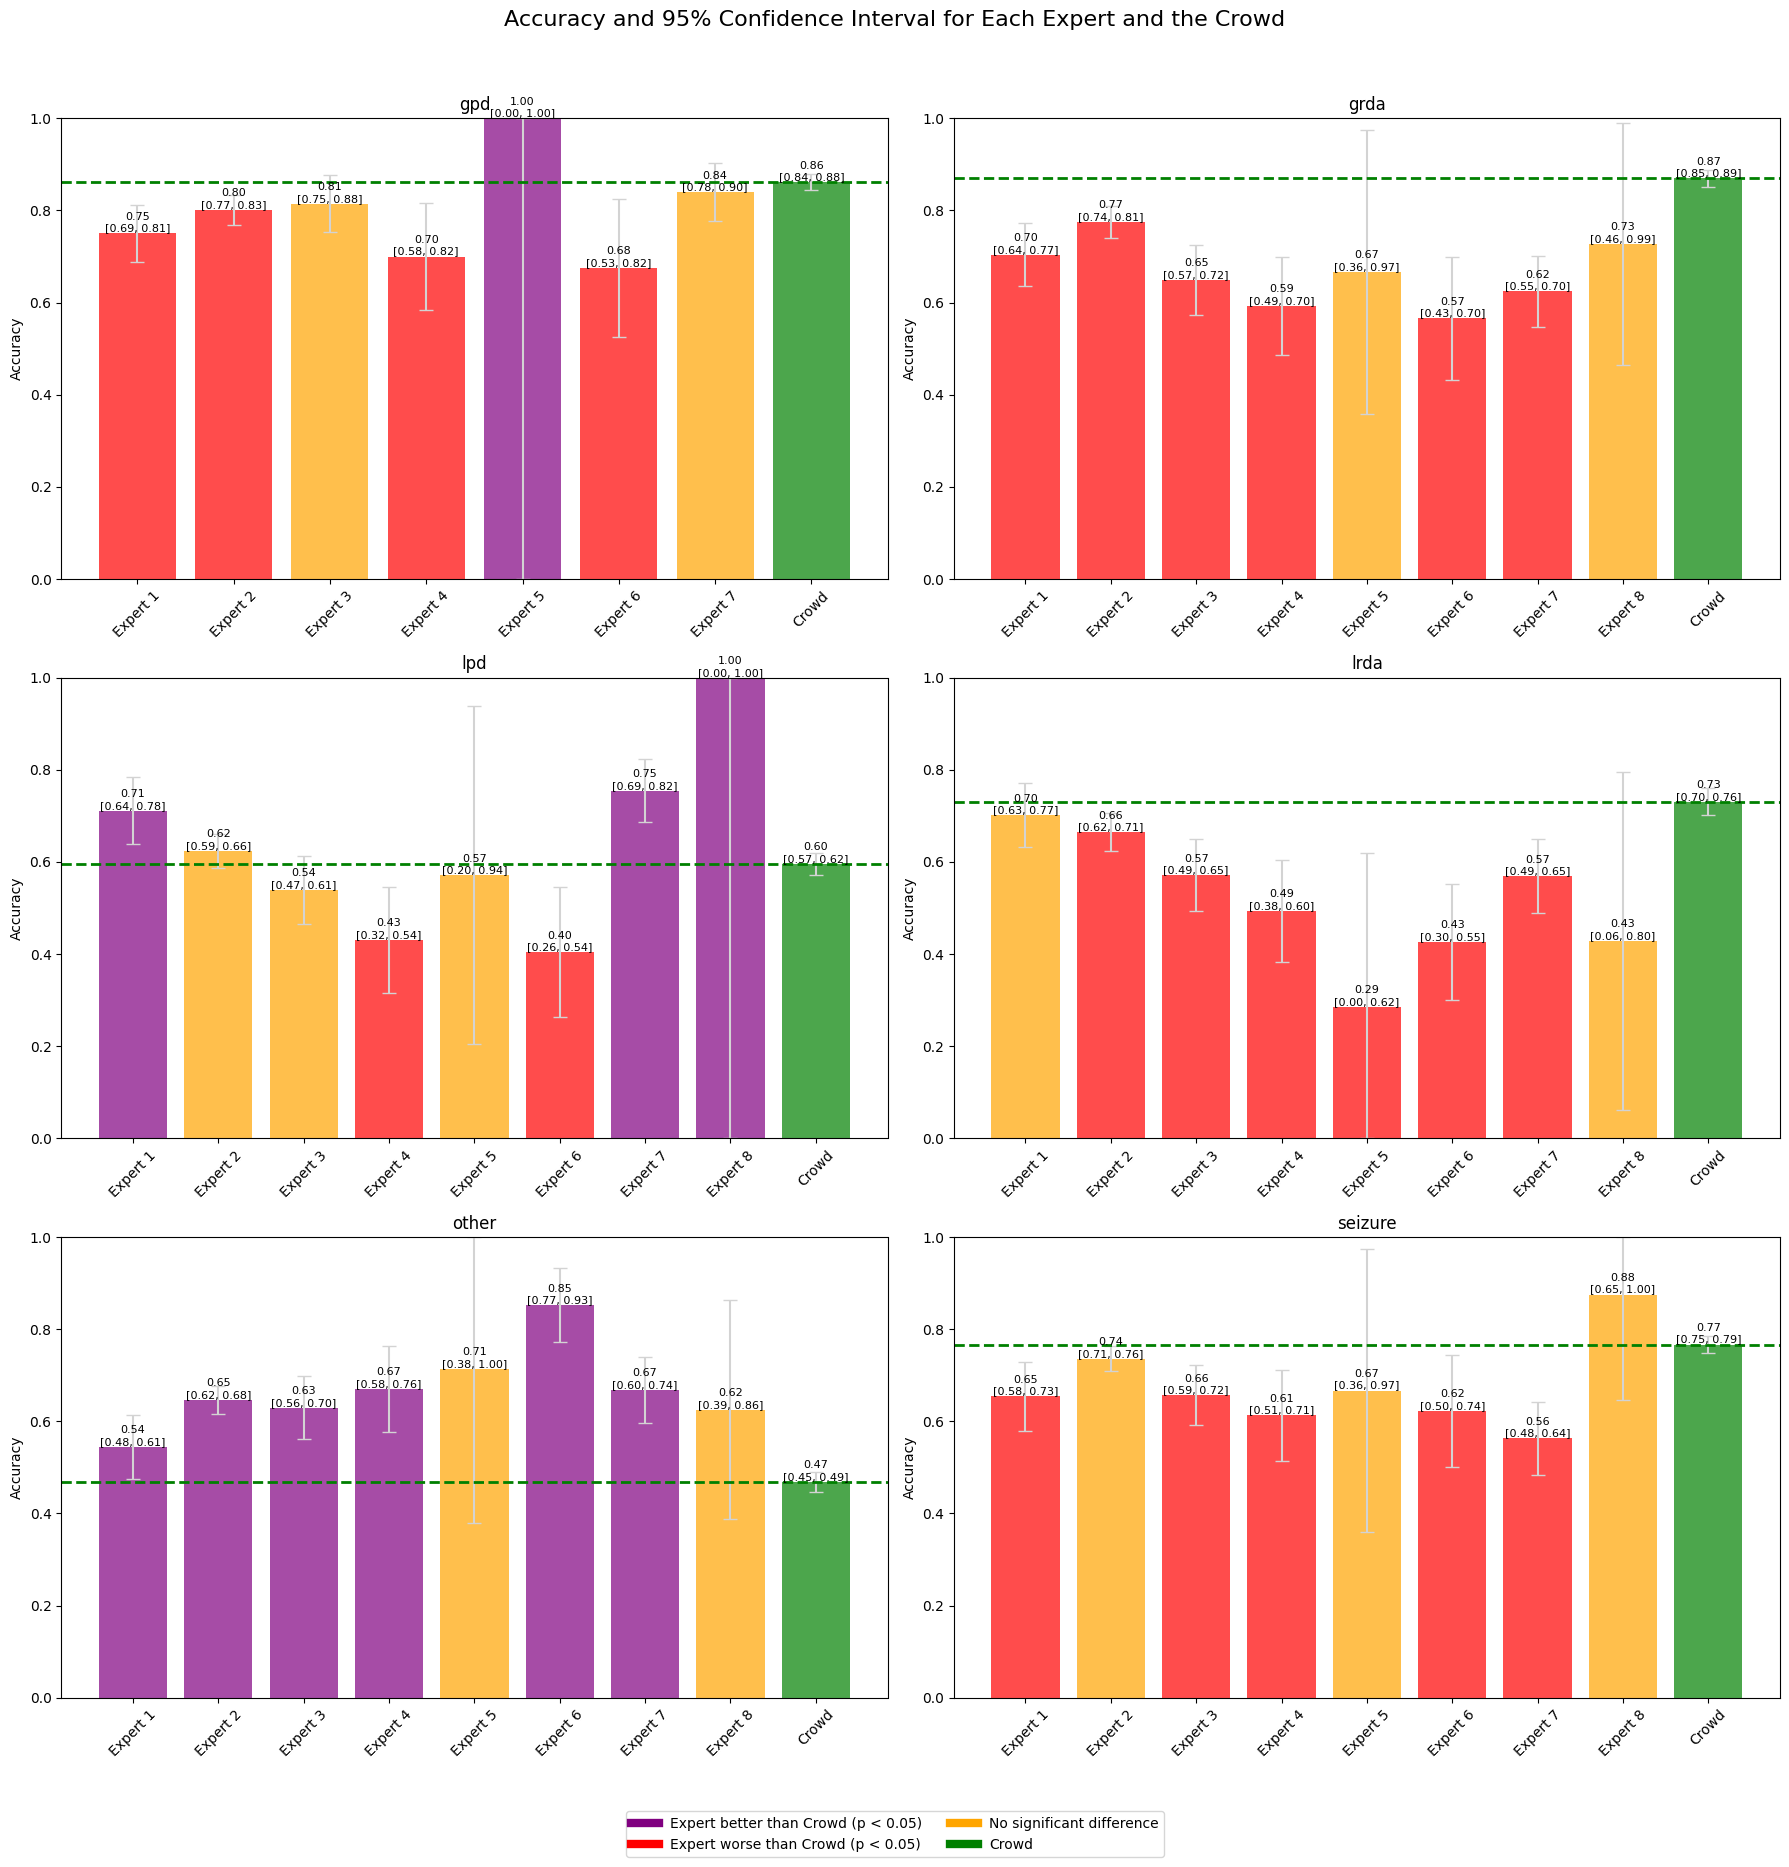

In [ ]:
import matplotlib.pyplot as plt

# expert_stratified_results from the previous step is used
non_expert_accuracies = {atype: res for (level, atype), res in stratified_results.items() if level == 'Non-Expert'}

# Organize expert accuracies by answer type
expert_accuracies_by_answer_type = {}
for (user_id, answer_type), (accuracy, ci, se, n) in expert_stratified_results.items():
    if n >= 5:  # Only include users who answered 5 or more unique problem IDs
        if answer_type not in expert_accuracies_by_answer_type:
            expert_accuracies_by_answer_type[answer_type] = {}
        expert_accuracies_by_answer_type[answer_type][user_id] = (accuracy, ci, se, n)

# Ensure we have all answer types represented
all_answer_types = sorted(set(non_expert_accuracies.keys()) | set(expert_accuracies_by_answer_type.keys()))

# Create the faceted charts
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for i, answer_type in enumerate(all_answer_types):
    if i >= len(axes):  # Avoid exceeding the number of prepared axes
        break
    ax = axes[i]

    # Prepare the data for plotting
    expert_data = expert_accuracies_by_answer_type.get(answer_type, {})
    user_ids = sorted(expert_data.keys()) + ['Crowd']  # Crowd represents the non-expert group

    # Accuracy values for each expert and for the Crowd
    accuracies = [expert_data.get(user_id, (0, (0, 0, 0)))[0] for user_id in user_ids[:-1]]  # List of expert accuracies
    accuracies += [non_expert_accuracies.get(answer_type, (0, (0, 0, 0)))[0]]  # Append non-expert accuracy

    # Confidence interval lower errors for each expert and for the Crowd
    ci_lower_errors = [expert_data.get(user_id, (0, (0, 0, 0)))[0] - expert_data.get(user_id, (0, (0, 0, 0)))[1][0] for user_id in user_ids[:-1]]  # List of lower CI errors for experts
    ci_lower_errors += [non_expert_accuracies.get(answer_type, (0, (0, 0, 0)))[0] - non_expert_accuracies.get(answer_type, (0, (0, 0, 0)))[1][0]]  # Append lower CI error for non-expert

    # Confidence interval upper errors for each expert and for the Crowd
    ci_upper_errors = [expert_data.get(user_id, (0, (0, 0, 0)))[1][1] - expert_data.get(user_id, (0, (0, 0, 0)))[0] for user_id in user_ids[:-1]]  # List of upper CI errors for experts
    ci_upper_errors += [non_expert_accuracies.get(answer_type, (0, (0, 0, 0)))[1][1] - non_expert_accuracies.get(answer_type, (0, (0, 0, 0)))[0]]  # Append upper CI error for non-expert

    # Combine lower and upper errors for use in bar chart error bars
    error_bars = [ci_lower_errors, ci_upper_errors]

    # Determine bar colors based on accuracy difference and p-value
    colors = []
    for user_id in user_ids[:-1]:
        accuracy_diff, z_score, p_value = accuracy_diff_results.get((user_id, answer_type), (0, 0, 1))
        if p_value < 0.05:
            if accuracy_diff < 0:
                colors.append('red')  # Negative difference, significant
            else:
                colors.append('purple')  # Positive difference, significant
        else:
            colors.append('orange')  # Not significant
    colors.append('green')  # Color for 'Crowd'

    # Plotting
    bars = ax.bar(range(len(user_ids)), accuracies, yerr=error_bars, capsize=5, alpha=0.7, color=colors, ecolor='lightgrey')
    ax.axhline(y=non_expert_accuracies.get(answer_type, (0, (0, 0, 0)))[0], color='green', linestyle='--', linewidth=2, label='Crowd Accuracy')  # Crowd accuracy reference line
    ax.set_title(f'{answer_type}')
    ax.set_xticks(range(len(user_ids)))
    ax.set_xticklabels(['Expert ' + str(i+1) for i in range(len(user_ids)-1)] + ['Crowd'], rotation=45)
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)  # Adjust based on your data scale

    # Adding text annotations for accuracy and CI for each expert and the crowd
    for bar, accuracy, (lower, upper) in zip(bars, accuracies, zip(ci_lower_errors, ci_upper_errors)):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f'{accuracy:.2f}\n[{accuracy - lower:.2f}, {accuracy + upper:.2f}]',
                ha='center', va='bottom', fontsize=8)

# Hide unused axes if there are fewer than six answer types
for j in range(i + 1, 6):
    axes[j].axis('off')  # Alternatively, you can use fig.delaxes(axes[j])

# Add a main title for the entire figure
fig.suptitle('Accuracy and 95% Confidence Interval for Each Expert and the Crowd', fontsize=16)

# Custom legend below the graph
legend_handles = [
    plt.Line2D([0], [0], color='purple', lw=6, label='Expert better than Crowd (p < 0.05)'),
    plt.Line2D([0], [0], color='red', lw=6, label='Expert worse than Crowd (p < 0.05)'),
    plt.Line2D([0], [0], color='orange', lw=6, label='No significant difference'),
    plt.Line2D([0], [0], color='green', lw=6, label='Crowd'),
]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the main title and legend
plt.show()


Supplemental S5


<ipython-input-23-8ff4abbd8e8d>:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = data.groupby('problem_id').apply(
<ipython-input-23-8ff4abbd8e8d>:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = data.groupby('problem_id').apply(
<ipython-input-23-8ff4abbd8e8d>:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, 

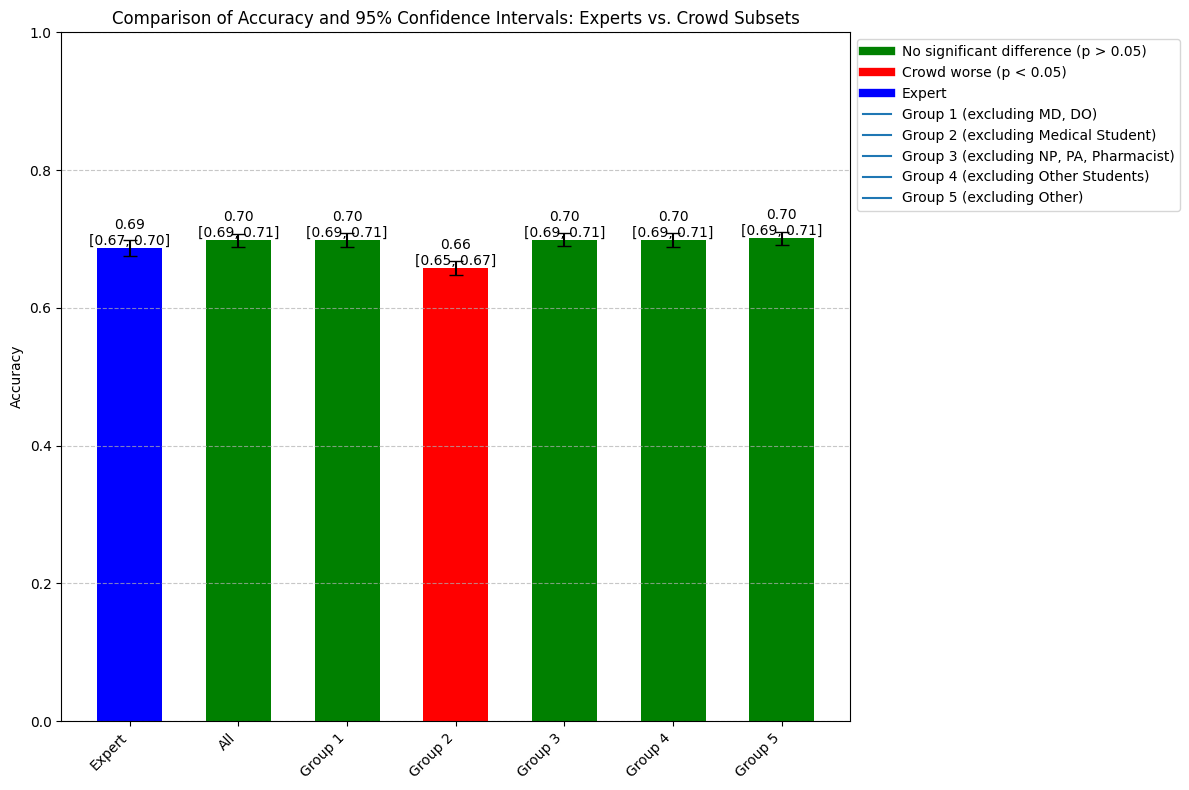

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Stratify by expert level
experts = df[df['experience_level'] == 'Expert']
non_experts = df[df['experience_level'] != 'Expert']

def compute_majority_accuracy(data):
    majority_answer = data.groupby('problem_id').apply(
        lambda x: (x.groupby('title')['combinedaccuracy'].sum()).idxmax()
    )
    correct_answers = data.groupby('problem_id')['goldstandardnew'].first()
    majority_correct = (majority_answer == correct_answers).fillna(False)

    accuracy = majority_correct.mean()
    n = data['problem_id'].nunique()
    correct_n = majority_correct.sum()
    se = np.sqrt(accuracy * (1 - accuracy) / n)
    ci = stats.norm.interval(0.95, loc=accuracy, scale=se)

    return accuracy, ci, n, correct_n

def compute_p_value(expert_accuracy, expert_n, crowd_accuracy, crowd_n):
    pooled_accuracy = (expert_accuracy * expert_n + crowd_accuracy * crowd_n) / (expert_n + crowd_n)
    se_diff = np.sqrt(pooled_accuracy * (1 - pooled_accuracy) * (1/expert_n + 1/crowd_n))
    z_score = (expert_accuracy - crowd_accuracy) / se_diff
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
    return p_value

# Compute expert accuracy and CI
expert_accuracy, expert_ci, expert_n, expert_correct_n = compute_majority_accuracy(experts)

# Define the subsets for the crowd
subsets = {
    'All': non_experts,
    'Group 1 (excluding MD, DO)': non_experts[~non_experts['experience_level'].isin(['MD', 'DO'])],
    'Group 2 (excluding Medical Student)': non_experts[~non_experts['experience_level'].isin(['Medical Student'])],
    'Group 3 (excluding NP, PA, Pharmacist)': non_experts[~non_experts['experience_level'].isin(['NP', 'PA', 'Pharmacist'])],
    'Group 4 (excluding Other Students)': non_experts[~non_experts['experience_level'].isin(['NP Student', 'PA Student', 'Pharmacy Student', 'Other Healthcare Student'])],
    'Group 5 (excluding Other)': non_experts[~non_experts['experience_level'].isin(['Other'])]
}

# Calculate accuracy, CI, and p-values for each subset
subset_accuracies = {}
for name, subset in subsets.items():
    accuracy, ci, n, correct_n = compute_majority_accuracy(subset)
    p_value = compute_p_value(expert_accuracy, expert_n, accuracy, n)
    subset_accuracies[name] = {
        'accuracy': accuracy,
        'ci': ci,
        'p_value': p_value
    }

# Plotting
plt.figure(figsize=(12, 8))

# Create x positions for the bar chart
x_positions = np.arange(len(subset_accuracies) + 1)  # +1 for the expert group

# Plot the expert bar
plt.bar([0], [expert_accuracy], color='blue', label='Expert', width=0.6,
        yerr=[[expert_accuracy - expert_ci[0]], [expert_ci[1] - expert_accuracy]], capsize=5)
plt.text(0, expert_accuracy, f'{expert_accuracy:.2f}\n[{expert_ci[0]:.2f}, {expert_ci[1]:.2f}]',
         ha='center', va='bottom', fontsize=10)

# Plot crowd subsets bars
for i, (name, values) in enumerate(subset_accuracies.items()):
    color = 'red' if values['p_value'] < 0.05 else 'green'
    plt.bar([x_positions[i + 1]], [values['accuracy']], color=color, label=name, width=0.6,
            yerr=[[values['accuracy'] - values['ci'][0]], [values['ci'][1] - values['accuracy']]], capsize=5)
    plt.text(x_positions[i + 1], values['accuracy'], f'{values["accuracy"]:.2f}\n[{values["ci"][0]:.2f}, {values["ci"][1]:.2f}]',
             ha='center', va='bottom', fontsize=10)

# Adjust the x-axis labels
plt.xticks(x_positions, ['Expert'] + ['All', 'Group 1', 'Group 2', 'Group 3', 'Group 4', 'Group 5'], rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # y-axis starting from 0
plt.title('Comparison of Accuracy and 95% Confidence Intervals: Experts vs. Crowd Subsets')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Create custom legends for bar colors and group descriptions
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='green', lw=6, label='No significant difference (p > 0.05)'),
    Line2D([0], [0], color='red', lw=6, label='Crowd worse (p < 0.05)'),
    Line2D([0], [0], color='blue', lw=6, label='Expert')
]

# Original legend for groups
group_lines = [
    Line2D([0], [0], label='Group 1 (excluding MD, DO)'),
    Line2D([0], [0], label='Group 2 (excluding Medical Student)'),
    Line2D([0], [0], label='Group 3 (excluding NP, PA, Pharmacist)'),
    Line2D([0], [0], label='Group 4 (excluding Other Students)'),
    Line2D([0], [0], label='Group 5 (excluding Other)')
]

# Combine both legends into one
plt.legend(handles=custom_lines + group_lines, loc='upper left', bbox_to_anchor=(1, 1))

# Show plot
plt.tight_layout()
plt.show()


Supplemental s5

<ipython-input-24-a3599cc0431f>:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = subset.groupby('problem_id').apply(
<ipython-input-24-a3599cc0431f>:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = subset.groupby('problem_id').apply(
<ipython-input-24-a3599cc0431f>:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecat

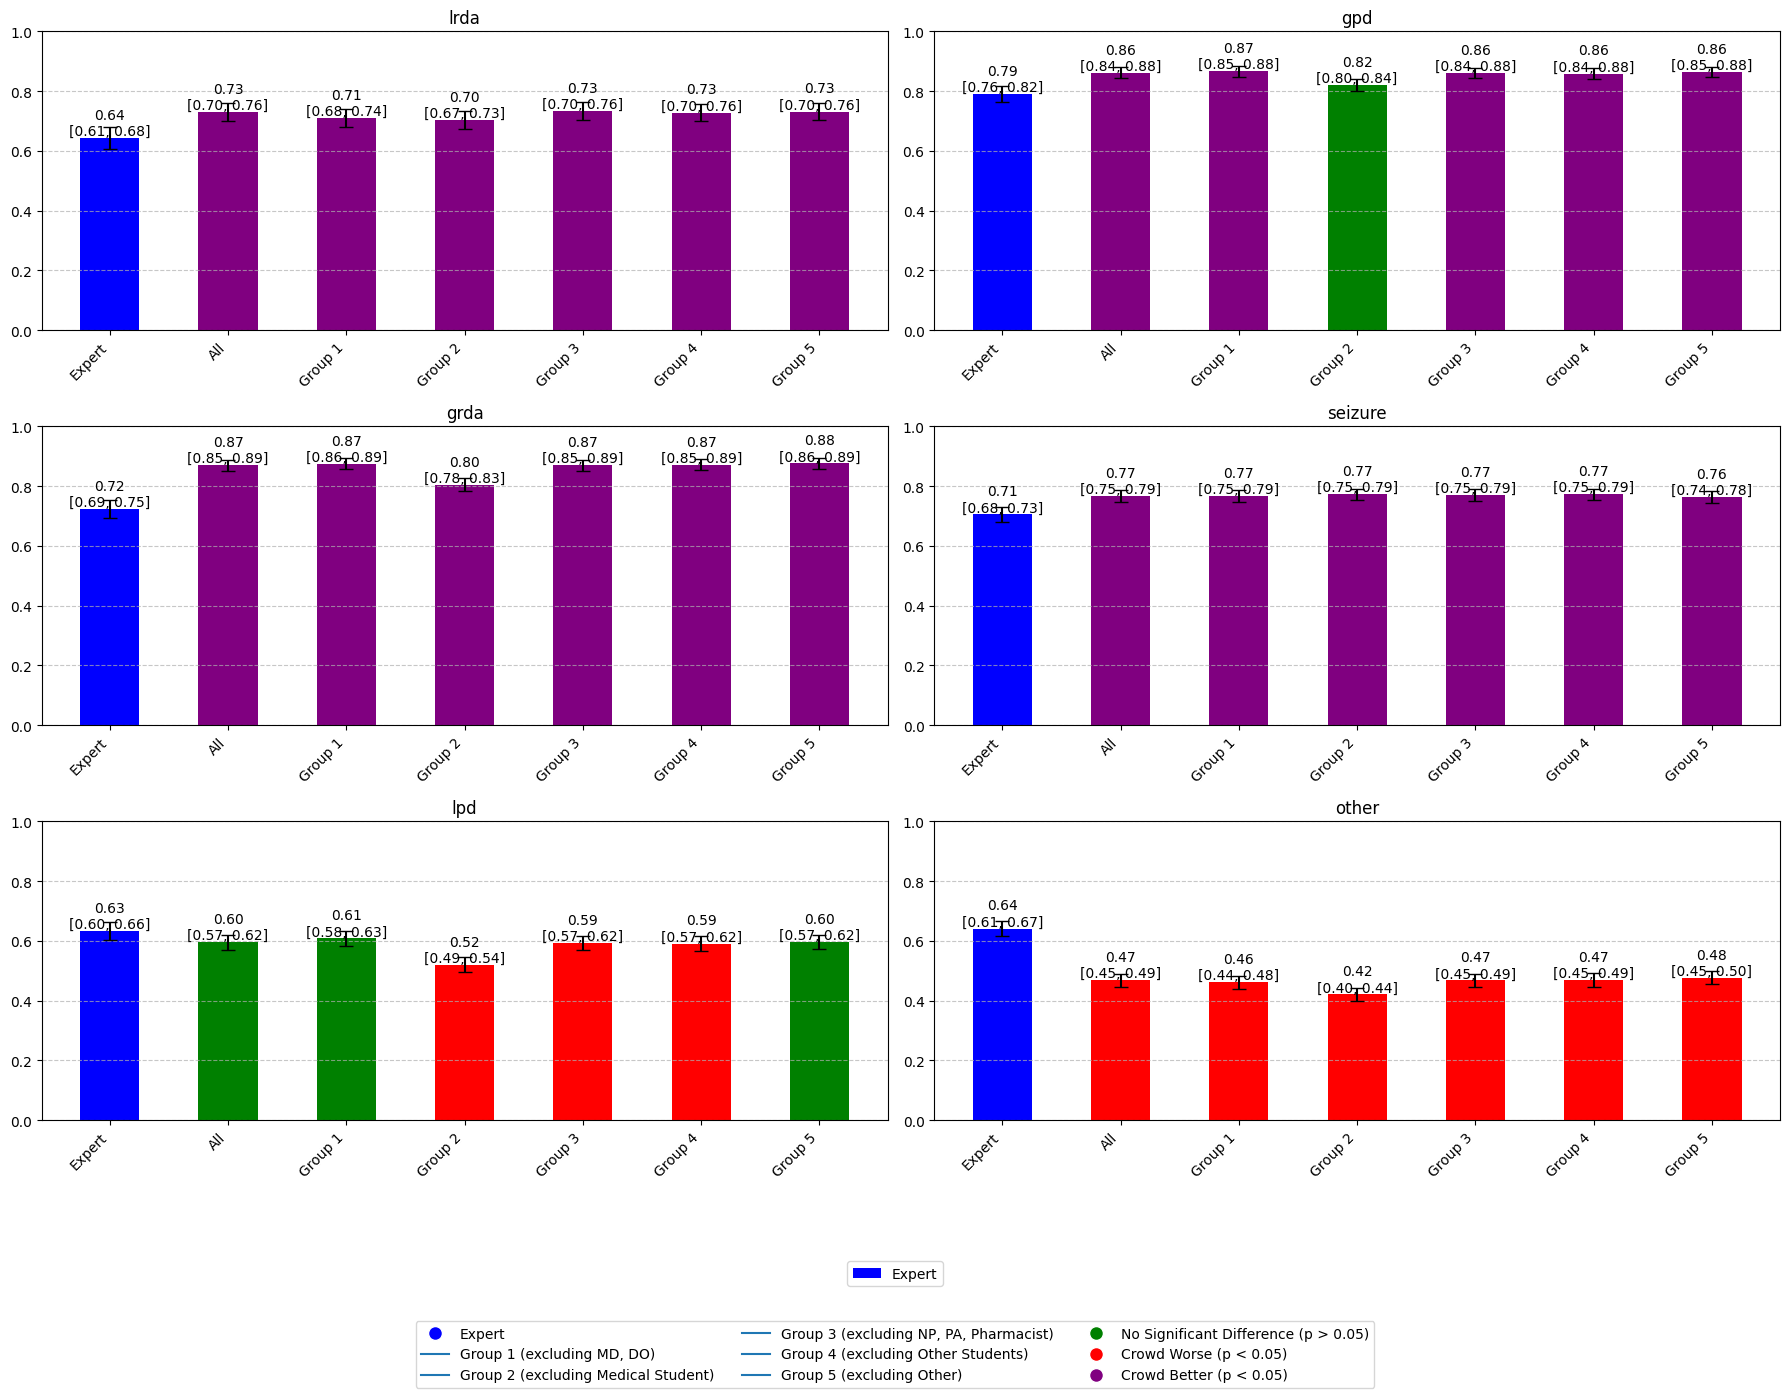

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

#df is DataFrame and already loaded

# Define the subsets for the crowd and stratify by answer type within each experience level group
subsets = {
    'All': df[df['experience_level'] != 'Expert'],
    'Group 1 (excluding MD, DO)': df[(df['experience_level'] != 'Expert') & (~df['experience_level'].isin(['MD', 'DO']))],
    'Group 2 (excluding Medical Student)': df[(df['experience_level'] != 'Expert') & (~df['experience_level'].isin(['Medical Student']))],
    'Group 3 (excluding NP, PA, Pharmacist)': df[(df['experience_level'] != 'Expert') & (~df['experience_level'].isin(['NP', 'PA', 'Pharmacist']))],
    'Group 4 (excluding Other Students)': df[(df['experience_level'] != 'Expert') & (~df['experience_level'].isin(['NP Student', 'PA Student', 'Pharmacy Student', 'Other Healthcare Student']))],
    'Group 5 (excluding Other)': df[(df['experience_level'] != 'Expert') & (~df['experience_level'].isin(['Other']))]
}

patterns = df['goldstandardnew'].unique()

def compute_majority_accuracy(data, pattern):
    subset = data[data['goldstandardnew'] == pattern]
    majority_answer = subset.groupby('problem_id').apply(
        lambda x: (x.groupby('title')['combinedaccuracy'].sum()).idxmax()
    )
    correct_answers = subset.groupby('problem_id')['goldstandardnew'].first()
    majority_correct = (majority_answer == correct_answers).fillna(False)

    accuracy = majority_correct.mean()
    n = subset['problem_id'].nunique()
    se = np.sqrt(accuracy * (1 - accuracy) / n) if n > 0 else 0
    ci = stats.norm.interval(0.95, loc=accuracy, scale=se) if n > 0 else (0, 0)

    return accuracy, ci, n

def compute_p_value(expert_accuracy, expert_n, crowd_accuracy, crowd_n):
    pooled_accuracy = (expert_accuracy * expert_n + crowd_accuracy * crowd_n) / (expert_n + crowd_n)
    se_diff = np.sqrt(pooled_accuracy * (1 - pooled_accuracy) * (1/expert_n + 1/crowd_n))
    z_score = (expert_accuracy - crowd_accuracy) / se_diff
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
    return p_value

# Set up the 3x2 grid for plotting
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
axes = axes.flatten()  # Flatten the 2D array of axes into a 1D array

# Iterate over each pattern and compute accuracies and CI for each group
for idx, pattern in enumerate(patterns):
    ax = axes[idx]

    expert_subset = df[(df['experience_level'] == 'Expert') & (df['goldstandardnew'] == pattern)]
    expert_accuracy, expert_ci, expert_n = compute_majority_accuracy(expert_subset, pattern)

    # Plot expert accuracy as a bar
    ax.bar([0], [expert_accuracy], color='blue', label=f'Expert', width=0.5, yerr=[[expert_accuracy - expert_ci[0]], [expert_ci[1] - expert_accuracy]], capsize=5)
    ax.text(0, expert_accuracy, f'{expert_accuracy:.2f}\n[{expert_ci[0]:.2f}, {expert_ci[1]:.2f}]', ha='center', va='bottom', fontsize=10)

    x_positions = np.linspace(1, 6, len(subsets))

    # Plot crowd subsets as bars
    for i, (name, subset) in enumerate(subsets.items()):
        crowd_accuracy, crowd_ci, crowd_n = compute_majority_accuracy(subset, pattern)
        p_value = compute_p_value(expert_accuracy, expert_n, crowd_accuracy, crowd_n)

        # Determine the color based on p-value and accuracy comparison
        if p_value > 0.05:
            color = 'green'
        elif crowd_accuracy < expert_accuracy and p_value < 0.05:
            color = 'red'
        elif crowd_accuracy > expert_accuracy and p_value < 0.05:
            color = 'purple'

        ax.bar([x_positions[i]], [crowd_accuracy], color=color, label=f'{name}' if pattern == patterns[0] else "", width=0.5, yerr=[[crowd_accuracy - crowd_ci[0]], [crowd_ci[1] - crowd_accuracy]], capsize=5)
        ax.text(x_positions[i], crowd_accuracy, f'{crowd_accuracy:.2f}\n[{crowd_ci[0]:.2f}, {crowd_ci[1]:.2f}]', ha='center', va='bottom', fontsize=10)

    # Set axis labels and title
    ax.set_xticks([0] + list(x_positions))
    ax.set_xticklabels(['Expert'] + ['All', 'Group 1', 'Group 2', 'Group 3', 'Group 4', 'Group 5'], rotation=45, ha='right')
    ax.set_ylim(0, 1)  # y-axis starting from 0
    ax.set_title(f'{pattern}')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout and add the legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=10)

# Add a color meaning legend with group details
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Expert', markerfacecolor='blue', markersize=10),
    plt.Line2D([0], [0], label='Group 1 (excluding MD, DO)'),
    plt.Line2D([0], [0], label='Group 2 (excluding Medical Student)'),
    plt.Line2D([0], [0], label='Group 3 (excluding NP, PA, Pharmacist)'),
    plt.Line2D([0], [0], label='Group 4 (excluding Other Students)'),
    plt.Line2D([0], [0], label='Group 5 (excluding Other)'),
    plt.Line2D([0], [0], marker='o', color='w', label='No Significant Difference (p > 0.05)', markerfacecolor='green', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Crowd Worse (p < 0.05)', markerfacecolor='red', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Crowd Better (p < 0.05)', markerfacecolor='purple', markersize=10)
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
!pip install joblib tqdm

<ipython-input-9-aad5b39bff44>:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = data.groupby('problem_id').apply(
Bootstrapping:   2%|▏         | 24/1000 [00:26<18:10,  1.12s/it]/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(

Processing Sample Sizes: 100%|██████████| 10/10 [9:00:24<00:00, 3242.50s/it]


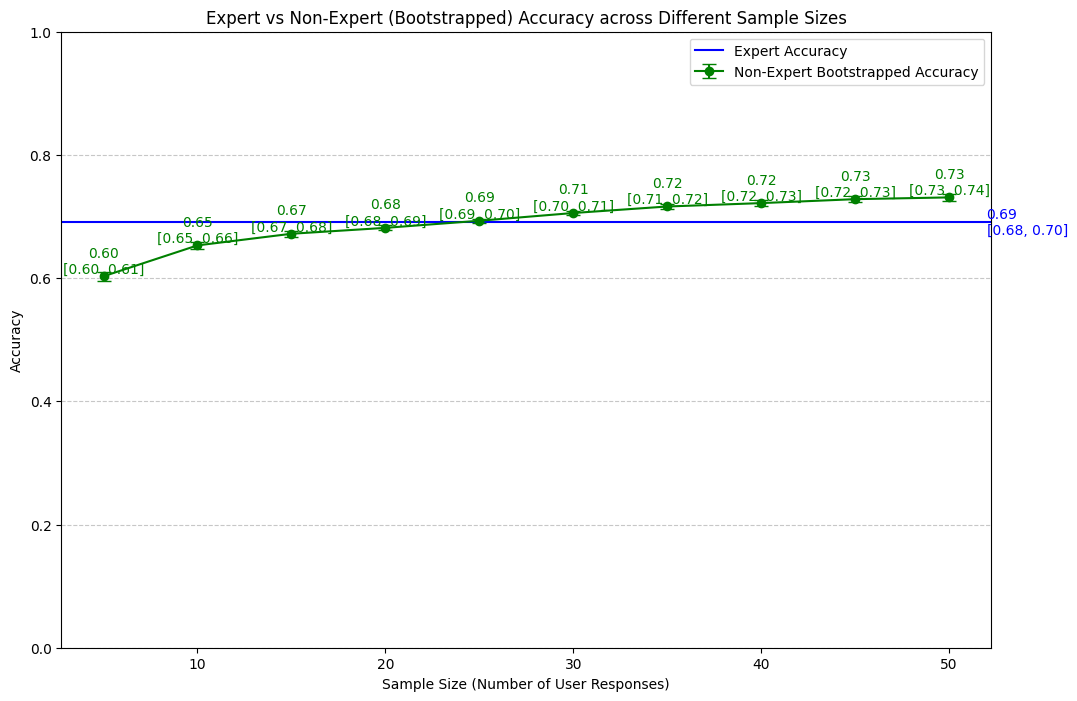

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import random
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm

# Assuming df is your DataFrame
# Step 1: Stratify by expert level
experts = df[df['experience_level'] == 'Expert']
non_experts = df[df['experience_level'] != 'Expert']

def compute_majority_accuracy(data):
    # Step 2: Compute majority vote and correctness
    majority_answer = data.groupby('problem_id').apply(
        lambda x: (x.groupby('title')['combinedaccuracy'].sum()).idxmax()
    )
    correct_answers = data.groupby('problem_id')['goldstandardnew'].first()
    majority_correct = (majority_answer == correct_answers).fillna(False)

    # Step 3: Calculate accuracy and 95% CI
    accuracy = majority_correct.mean()
    n = data['problem_id'].nunique()  # Total problems evaluated
    se = np.sqrt(accuracy * (1 - accuracy) / n)
    ci = stats.norm.interval(0.95, loc=accuracy, scale=se)

    return accuracy, ci

# Compute for experts
expert_accuracy, expert_ci = compute_majority_accuracy(experts)

# Step 2: Sensitivity analysis for non-experts
def bootstrap_majority_accuracy(data, sample_size, n_bootstrap=10):
    problem_ids = data['problem_id'].unique()
    bootstrapped_accuracies = []

    def bootstrap_iteration(_):
        sampled_data_list = []

        for pid in problem_ids:
            filtered_data = data[data['problem_id'] == pid]
            if filtered_data['user_id'].nunique() > sample_size:
                sampled_users = random.sample(list(filtered_data['user_id'].unique()), sample_size)
                sampled_data_list.append(filtered_data[filtered_data['user_id'].isin(sampled_users)])

        if sampled_data_list:
            sampled_data = pd.concat(sampled_data_list)
            accuracy, _ = compute_majority_accuracy(sampled_data)
            return accuracy
        return None

    bootstrapped_accuracies = Parallel(n_jobs=-1)(delayed(bootstrap_iteration)(_) for _ in tqdm(range(n_bootstrap), desc="Bootstrapping"))

    # Filter out None values if any
    bootstrapped_accuracies = [acc for acc in bootstrapped_accuracies if acc is not None]

    # Calculate the average accuracy over the bootstrap samples
    avg_bootstrap_accuracy = np.mean(bootstrapped_accuracies)

    # Calculate the 95% confidence interval using percentiles
    lower_bound = np.percentile(bootstrapped_accuracies, 2.5)
    upper_bound = np.percentile(bootstrapped_accuracies, 97.5)
    ci_bootstrap = (lower_bound, upper_bound)

    return avg_bootstrap_accuracy, ci_bootstrap

# Sample sizes to evaluate
sample_sizes = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

# Store results for plotting
non_expert_accuracies = []
non_expert_cis = []

for sample_size in tqdm(sample_sizes, desc="Processing Sample Sizes"):
    non_expert_accuracy, non_expert_ci = bootstrap_majority_accuracy(non_experts, sample_size, n_bootstrap=1000)
    non_expert_accuracies.append(non_expert_accuracy)
    non_expert_cis.append(non_expert_ci)

# Visualization
plt.figure(figsize=(12, 8))

# Plot expert accuracy (horizontal line)
plt.axhline(y=expert_accuracy, color='blue', linestyle='-', label='Expert Accuracy')
plt.text(x=sample_sizes[-1] + 2, y=expert_accuracy,
         s=f'{expert_accuracy:.2f}\n[{expert_ci[0]:.2f}, {expert_ci[1]:.2f}]',
         color='blue', va='center')

# Plot non-expert accuracies with error bars
lower_errors = [acc - ci[0] for acc, ci in zip(non_expert_accuracies, non_expert_cis)]
upper_errors = [ci[1] - acc for acc, ci in zip(non_expert_accuracies, non_expert_cis)]
yerr = [lower_errors, upper_errors]

plt.errorbar(sample_sizes, non_expert_accuracies,
             yerr=yerr, fmt='o-', color='green', capsize=5, label='Non-Expert Bootstrapped Accuracy')

# Annotate non-expert points
for i, (x, y, ci) in enumerate(zip(sample_sizes, non_expert_accuracies, non_expert_cis)):
    plt.text(x, y, f'{y:.2f}\n[{ci[0]:.2f}, {ci[1]:.2f}]', ha='center', va='bottom', color='green')

plt.ylim(0, 1)  # Start y-axis at 0
plt.xlabel('Sample Size (Number of User Responses)')
plt.ylabel('Accuracy')
plt.title('Expert vs Non-Expert (Bootstrapped) Accuracy across Different Sample Sizes')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


In [ ]:
bootstrap_results = pd.DataFrame({
    'sample_size': sample_sizes,
    'non_expert_accuracy': non_expert_accuracies,
    'non_expert_ci_lower': [ci[0] for ci in non_expert_cis],
    'non_expert_ci_upper': [ci[1] for ci in non_expert_cis]
})

# Save the DataFrame to a CSV file
file_path = '/content/drive/MyDrive/Colab Notebooks/bootstrap_accuracy_results.csv'
bootstrap_results.to_csv(file_path, index=False)
print("Bootstrap results have been saved to 'bootstrap_accuracy_results.csv'.")

Bootstrap results have been saved to 'bootstrap_accuracy_results.csv'.


In [ ]:
your_path = "/content/drive/MyDrive/Colab Notebooks/For JJ- code for figures "

import pathlib
import tempfile

import google.colab
import nbformat
import nbconvert

def download_html(drive_path, mount_dir="/content/drive/"):
  drive_path = pathlib.Path(drive_path)
  notebook_path = pathlib.Path(mount_dir) / 'MyDrive' / drive_path

  # open notebook
  with open(notebook_path) as f:
    notebook = nbformat.reads(f.read(), as_version=nbformat.NO_CONVERT)

  # export to HTML string
  html_exporter = nbconvert.HTMLExporter(template_name = 'classic')
  html, _resources = html_exporter.from_notebook_node(notebook)

  # write and download tmp_file

  tmp_html = (pathlib.Path('/tmp/') / drive_path.name).with_suffix(".html")
  with open(tmp_html, "w") as tmp:
    tmp.write(html)

  google.colab.files.download(tmp_html)

google.colab.drive.mount("/content/drive/")
download_html(your_path)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
New sensitivity analysis

In [ ]:
#crowd vs individual expert for overall, not used
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.weightstats import ttest_ind

# ----------------------------
# 1. Data Preparation
# ----------------------------
# Assume df already exists with the following columns:
# - user_id: unique identifier for a user
# - title: the answer provided
# - goldstandardnew: the correct answer
# - experience_level: "Expert" for expert responses; any other value for crowd responses
# - problem_id: identifier for the problem
# - combinedaccuracy: a numeric weight for crowd's weighted accuracy

# Create a binary correctness indicator for non‐weighted accuracy.
df['correct'] = (df['title'] == df['goldstandardnew']).astype(int)

# Define the function to compute crowd weighted accuracy.
def compute_weighted_accuracy(sub_df):
    # For a given problem, group by answer and sum combinedaccuracy
    pred = sub_df.groupby('title')['combinedaccuracy'].sum().idxmax()
    gold = sub_df['goldstandardnew'].iloc[0]
    return int(pred == gold)

# ----------------------------
# 2. Label Experts Using user_id
# ----------------------------
# Filter the expert responses.
df_expert = df[df['experience_level'] == "Expert"].copy()

# Identify the unique expert user_ids and assign sequential labels.
unique_experts = sorted(df_expert['user_id'].unique())
expert_mapping = {uid: f"expert{i+1}" for i, uid in enumerate(unique_experts)}
print("Expert mapping:", expert_mapping)

# Add a new column 'expert_label' based on the mapping.
df_expert['expert_label'] = df_expert['user_id'].map(expert_mapping)

# ----------------------------
# 3. Aggregate Performance per Problem
# ----------------------------
# 3a. Expert Aggregation:
# Compute non‐weighted accuracy per problem for each expert.
agg_experts = df_expert.groupby(['problem_id', 'expert_label'])['correct'].mean().unstack()
# Fill missing values if an expert did not answer a problem (optional)
agg_experts = agg_experts.fillna(0)
# Standardize column names (e.g., expert1, expert2, etc.)
agg_experts.columns = agg_experts.columns.str.lower()
print("Aggregated expert columns:", agg_experts.columns.tolist())

# 3b. Crowd Aggregation:
# Define crowd responses as those with experience_level other than "Expert".
df_crowd = df[df['experience_level'] != "Expert"]
crowd_accuracy = df_crowd.groupby('problem_id').apply(compute_weighted_accuracy)
crowd_accuracy = crowd_accuracy.rename('crowd')

# 3c. Average Questions Per User per Problem:
# For each problem, compute the average number of answers provided per user.
avg_questions = (df.groupby(['problem_id', 'user_id'])
                   .size()
                   .groupby('problem_id')
                   .mean()
                   .rename('avg_questions'))

# 3d. Merge the Aggregated Data:
# Merge expert accuracies, crowd accuracy, and average questions into one DataFrame.
agg_performance = agg_experts.merge(crowd_accuracy, left_index=True, right_index=True)
agg_performance = agg_performance.merge(avg_questions, left_index=True, right_index=True)
agg_performance.reset_index(inplace=True)
print("\nAggregated performance (first few rows):")
print(agg_performance.head())

# ----------------------------
# 4. Build and Fit Separate Models for Each Expert vs. Crowd
# ----------------------------
# For each expert, we’ll create a long-format DataFrame
# where each problem contributes two rows:
# one row for the expert's accuracy and one for the crowd's accuracy.
results = {}
for expert in agg_experts.columns:
    # Create long-format data.
    df_model = pd.melt(
        agg_performance,
        id_vars=['problem_id', 'avg_questions'],
        value_vars=[expert, 'crowd'],
        var_name='group',
        value_name='accuracy'
    )

    # Drop any problems with missing accuracy (if any).
    df_model = df_model.dropna(subset=['accuracy'])

    # Convert group to a categorical variable.
    df_model['group'] = df_model['group'].astype('category')

    print(f"\nData preview for {expert} vs. crowd:")
    print(df_model.head())

    # Fit a mixed-effects model with problem_id as a random effect.
    # The fixed effects include 'group' (expert vs. crowd) and 'avg_questions'.
    formula = "accuracy ~ group + avg_questions"
    print("\nModel formula:")
    print(formula)

    # Using a mixed linear model (random intercept per problem)
    model = smf.mixedlm(formula, data=df_model, groups=df_model["problem_id"])
    res = model.fit()
    print(f"\nMixed-Effects Model Summary for {expert} vs. crowd:")
    print(res.summary())

    # Save the result for further inspection if needed.
    results[expert] = res


Expert mapping: {np.int64(41816): 'expert1', np.int64(123180): 'expert2', np.int64(129198): 'expert3', np.int64(129968): 'expert4', np.int64(129995): 'expert5', np.int64(130067): 'expert6', np.int64(130226): 'expert7', np.int64(130262): 'expert8'}
Aggregated expert columns: ['expert1', 'expert2', 'expert3', 'expert4', 'expert5', 'expert6', 'expert7', 'expert8']


<ipython-input-16-b6044bccd34f>:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  crowd_accuracy = df_crowd.groupby('problem_id').apply(compute_weighted_accuracy)



Aggregated performance (first few rows):
   problem_id  expert1  expert2  expert3  expert4  expert5  expert6  expert7  \
0     4958127      1.0      0.0      0.0      0.0      0.0      0.0      0.0   
1     4958130      0.0      1.0      0.0      0.0      0.0      0.0      0.0   
2     4958133      0.0      1.0      0.0      0.0      0.0      0.0      0.0   
3     4958134      0.0      1.0      0.0      0.0      0.0      0.0      0.0   
4     4958136      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

   expert8  crowd  avg_questions  
0      0.0      1       1.764706  
1      0.0      0       1.615385  
2      0.0      1       1.636364  
3      0.0      1       1.413793  
4      0.0      0       1.619048  

Data preview for expert1 vs. crowd:
   problem_id  avg_questions    group  accuracy
0     4958127       1.764706  expert1       1.0
1     4958130       1.615385  expert1       0.0
2     4958133       1.636364  expert1       0.0
3     4958134       1.413793  expert1 

/usr/local/lib/python3.11/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



Mixed-Effects Model Summary for expert4 vs. crowd:
            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  accuracy  
No. Observations:    11760    Method:              REML      
No. Groups:          5880     Scale:               0.1219    
Min. group size:     2        Log-Likelihood:      -4546.2175
Max. group size:     2        Converged:           Yes       
Mean group size:     2.0                                     
-------------------------------------------------------------
                 Coef.  Std.Err.    z     P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept         0.567    0.036   15.887 0.000  0.497  0.637
group[T.expert4] -0.657    0.006 -101.999 0.000 -0.669 -0.644
avg_questions     0.106    0.027    3.894 0.000  0.052  0.159
Group Var         0.005    0.005                             


Data preview for expert5 vs. crowd:
   problem_id  avg_questions    group  accuracy
0     

...


Mixed-Effects Model Summary for expert5 vs. crowd:
            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  accuracy  
No. Observations:    11760    Method:              REML      
No. Groups:          5880     Scale:               0.1062    
Min. group size:     2        Log-Likelihood:      -3526.2358
Max. group size:     2        Converged:           Yes       
Mean group size:     2.0                                     
-------------------------------------------------------------
                 Coef.  Std.Err.    z     P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept         0.628    0.032   19.542 0.000  0.565  0.691
group[T.expert5] -0.700    0.006 -116.420 0.000 -0.712 -0.688
avg_questions     0.059    0.024    2.401 0.016  0.011  0.107
Group Var         0.000    0.004                             


Data preview for expert6 vs. crowd:
   problem_id  avg_questions    group  accuracy
0     

/usr/local/lib/python3.11/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



Mixed-Effects Model Summary for expert6 vs. crowd:
            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  accuracy  
No. Observations:    11760    Method:              REML      
No. Groups:          5880     Scale:               0.1160    
Min. group size:     2        Log-Likelihood:      -4252.3995
Max. group size:     2        Converged:           Yes       
Mean group size:     2.0                                     
-------------------------------------------------------------
                 Coef.  Std.Err.    z     P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept         0.571    0.035   16.403 0.000  0.503  0.639
group[T.expert6] -0.670    0.006 -106.687 0.000 -0.682 -0.658
avg_questions     0.103    0.026    3.881 0.000  0.051  0.155
Group Var         0.005    0.005                             


Data preview for expert7 vs. crowd:
   problem_id  avg_questions    group  accuracy
0     

/usr/local/lib/python3.11/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



Mixed-Effects Model Summary for expert8 vs. crowd:
            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  accuracy  
No. Observations:    11760    Method:              REML      
No. Groups:          5880     Scale:               0.1061    
Min. group size:     2        Log-Likelihood:      -3549.0539
Max. group size:     2        Converged:           Yes       
Mean group size:     2.0                                     
-------------------------------------------------------------
                 Coef.  Std.Err.    z     P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept         0.625    0.032   19.366 0.000  0.562  0.689
group[T.expert8] -0.699    0.006 -116.374 0.000 -0.711 -0.687
avg_questions     0.061    0.025    2.476 0.013  0.013  0.109
Group Var         0.001    0.004                             



<ipython-input-31-753a1c9919fe>:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_data = combined.groupby(['problem_id', 'group']).apply(



Comparison for crowd subset: All
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_accuracy
No. Observations: 14774   Method:             REML             
No. Groups:       8894    Scale:              0.1254           
Min. group size:  1       Log-Likelihood:     -9003.4093       
Max. group size:  2       Converged:          Yes              
Mean group size:  1.7                                          
---------------------------------------------------------------
                      Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.652    0.011 60.016 0.000  0.630  0.673
group[T.All]          0.001    0.007  0.188 0.851 -0.013  0.015
avg_question_count    0.000    0.000  3.547 0.000  0.000  0.000
Group Var             0.087    0.011                           



<ipython-input-31-753a1c9919fe>:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_data = combined.groupby(['problem_id', 'group']).apply(



Comparison for crowd subset: Group 1
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_accuracy
No. Observations: 14774   Method:             REML             
No. Groups:       8894    Scale:              0.1284           
Min. group size:  1       Log-Likelihood:     -9040.1699       
Max. group size:  2       Converged:          Yes              
Mean group size:  1.7                                          
---------------------------------------------------------------
                      Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.653    0.011 59.610 0.000  0.631  0.674
group[T.Group 1]      0.005    0.007  0.720 0.471 -0.008  0.018
avg_question_count    0.000    0.000  3.416 0.001  0.000  0.000
Group Var             0.084    0.011                           



<ipython-input-31-753a1c9919fe>:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_data = combined.groupby(['problem_id', 'group']).apply(


...

<ipython-input-31-753a1c9919fe>:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_data = combined.groupby(['problem_id', 'group']).apply(



Comparison for crowd subset: Group 4
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_accuracy
No. Observations: 14774   Method:             REML             
No. Groups:       8894    Scale:              0.1252           
Min. group size:  1       Log-Likelihood:     -8999.3861       
Max. group size:  2       Converged:          Yes              
Mean group size:  1.7                                          
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.650    0.011 60.098 0.000  0.628  0.671
group[T.Group 4]     -0.003    0.008 -0.351 0.726 -0.018  0.012
avg_question_count    0.000    0.000  3.768 0.000  0.000  0.000
Group Var             0.087    0.011                           



<ipython-input-31-753a1c9919fe>:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_data = combined.groupby(['problem_id', 'group']).apply(



Comparison for crowd subset: Group 5
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_accuracy
No. Observations: 14774   Method:             REML             
No. Groups:       8894    Scale:              0.1238           
Min. group size:  1       Log-Likelihood:     -8963.6993       
Max. group size:  2       Converged:          Yes              
Mean group size:  1.7                                          
---------------------------------------------------------------
                      Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.653    0.011 60.370 0.000  0.632  0.674
group[T.Group 5]      0.001    0.008  0.123 0.902 -0.014  0.016
avg_question_count    0.000    0.000  3.407 0.001  0.000  0.000
Group Var             0.088    0.011                           


Final plot data:
     group  predicted  ci_lower  ci_upper  p_value       ref

<ipython-input-31-753a1c9919fe>:113: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_expert_only = df_expert.groupby('problem_id').apply(


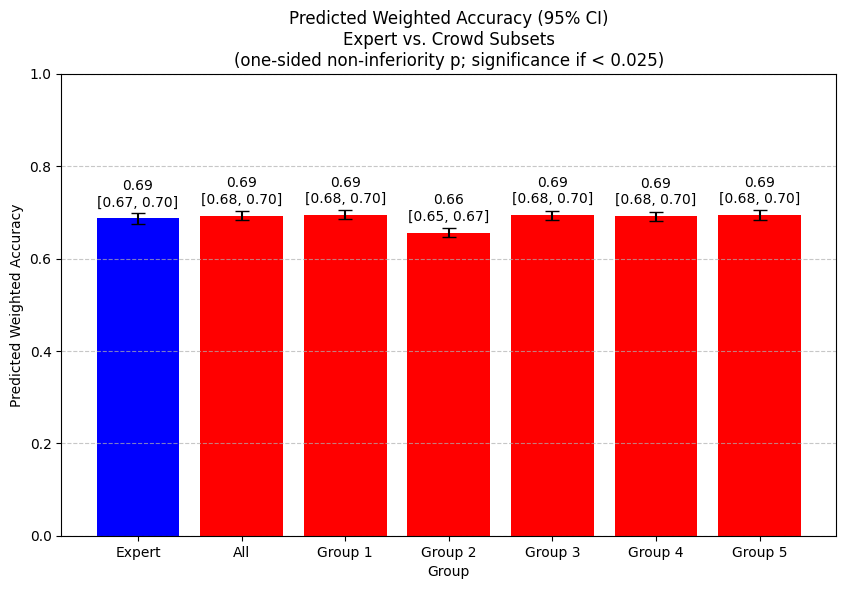

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from scipy import stats


df['correct'] = (df['title'] == df['goldstandardnew']).astype(int)
df['group'] = df['experience_level'].apply(lambda x: 'Expert' if x == 'Expert' else 'Crowd')
df['user_question_count'] = df.groupby('user_id')['problem_id'].transform('nunique')
def compute_weighted_accuracy(sub_df):
    # For a given problem, select the answer with highest summed combinedaccuracy.
    pred = sub_df.groupby('title')['combinedaccuracy'].sum().idxmax()
    gold = sub_df['goldstandardnew'].iloc[0]
    return int(pred == gold)

# Define non-expert (crowd) records.
non_experts = df[df['experience_level'] != 'Expert']

# ----------------------------
# 2. Define Crowd Subsets
# ----------------------------
subsets = {
    'All': non_experts,
    'Group 1': non_experts[~non_experts['experience_level'].isin(['MD', 'DO'])],
    'Group 2': non_experts[~non_experts['experience_level'].isin(['Medical Student'])],
    'Group 3': non_experts[~non_experts['experience_level'].isin(['NP', 'PA', 'Pharmacist'])],
    'Group 4': non_experts[~non_experts['experience_level'].isin(['NP Student', 'PA Student', 'Pharmacy Student', 'Other Healthcare Student'])],
    'Group 5': non_experts[~non_experts['experience_level'].isin(['Other'])]
}

# ----------------------------
# 3. Prepare Expert Data
# ----------------------------
df_expert = df[df['experience_level'] == 'Expert'].copy()
df_expert['group'] = 'Expert'

# ----------------------------
# 4. Fit Models for Each Crowd Subset vs. Expert and Extract Predictions
# ----------------------------
comparison_results = {}
noninf_margin = -0.05  # noninferiority margin (Expert - Crowd)
for key, subset_df in subsets.items():
    # Label the current crowd subset records.
    df_crowd_subset = subset_df.copy()
    df_crowd_subset['group'] = key  # e.g., "All", "Group 1", etc.

    # Combine Expert and current crowd subset records.
    combined = pd.concat([df_expert, df_crowd_subset], ignore_index=True)

    # Aggregate by problem: compute weighted_accuracy and average question count.
    agg_data = combined.groupby(['problem_id', 'group']).apply(
        lambda sub: pd.Series({
            'weighted_accuracy': compute_weighted_accuracy(sub),
            'avg_question_count': sub['user_question_count'].mean()
        })
    ).reset_index()

    # Set categorical order with Expert as the reference.
    agg_data['group'] = pd.Categorical(agg_data['group'], categories=['Expert', key], ordered=True)

    # Fit the mixed-effects model.
    model = smf.mixedlm("weighted_accuracy ~ group + avg_question_count", agg_data, groups=agg_data["problem_id"])
    res = model.fit()
    print(f"\nComparison for crowd subset: {key}")
    print(res.summary())

    # Extract fixed-effects parameters and covariance (fixed portion only).
    fixed_params = res.fe_params
    cov_full = res.cov_params()
    cov_fixed = cov_full.loc[fixed_params.index, fixed_params.index]

    # Compute the global average of avg_question_count.
    global_avg = agg_data['avg_question_count'].mean()

    # With Expert as reference, the design vectors are:
    # For Expert: [1, 0, global_avg]
    # For Crowd: [1, 1, global_avg]
    x_expert = np.array([1, 0, global_avg])
    x_crowd = np.array([1, 1, global_avg])

    pred_expert = np.dot(fixed_params, x_expert)
    pred_crowd = np.dot(fixed_params, x_crowd)

    se_expert = np.sqrt(np.dot(x_expert, np.dot(cov_fixed, x_expert)))
    se_crowd = np.sqrt(np.dot(x_crowd, np.dot(cov_fixed, x_crowd)))

    ci_expert = (pred_expert - 1.96 * se_expert, pred_expert + 1.96 * se_expert)
    ci_crowd = (pred_crowd - 1.96 * se_crowd, pred_crowd + 1.96 * se_crowd)

    # For a model like this, the difference between Expert and Crowd predictions is exactly the group coefficient.
    # Its standard error is:
    se_diff = np.sqrt(cov_fixed.loc[f"group[T.{key}]", f"group[T.{key}]"])
    diff = pred_expert - pred_crowd  # Note: This equals - (group coefficient)

    # Compute non-inferiority one-sided p-value:
    #   z = (diff - noninf_margin) / se_diff,   p = norm.cdf(z)
    z_noninf = (diff - noninf_margin) / se_diff
    one_sided_p = stats.norm.cdf(z_noninf)

    comparison_results[key] = {
        'predicted_expert': pred_expert,
        'ci_expert': ci_expert,
        'predicted_crowd': pred_crowd,
        'ci_crowd': ci_crowd,
        'noninf_diff': diff,  # Expert - Crowd difference
        'one_sided_p': one_sided_p
    }

# ----------------------------
# 4a. Compute Overall Expert Performance (Expert-only)
# ----------------------------
agg_expert_only = df_expert.groupby('problem_id').apply(
    lambda sub: pd.Series({
        'weighted_accuracy': compute_weighted_accuracy(sub),
        'avg_question_count': sub['user_question_count'].mean()
    })
).reset_index()
overall_expert = agg_expert_only['weighted_accuracy'].mean()
se_expert_overall = agg_expert_only['weighted_accuracy'].std() / np.sqrt(agg_expert_only['problem_id'].nunique())
ci_expert_overall = (overall_expert - 1.96 * se_expert_overall, overall_expert + 1.96 * se_expert_overall)

# ----------------------------
# 5. Assemble Data for Plotting
# ----------------------------
# X-axis: Expert, All, Group 1, Group 2, Group 3, Group 4, Group 5.
plot_rows = []

# Expert bar.
plot_rows.append({
    "group": "Expert",
    "predicted": overall_expert,
    "ci_lower": ci_expert_overall[0],
    "ci_upper": ci_expert_overall[1],
    "p_value": None,
    "ref": None
})
# Crowd subset bars.
for key, res_dict in comparison_results.items():
    plot_rows.append({
        "group": key,
        "predicted": res_dict['predicted_crowd'],
        "ci_lower": res_dict['ci_crowd'][0],
        "ci_upper": res_dict['ci_crowd'][1],
        "p_value": res_dict['one_sided_p'],  # one-sided non-inferiority p-value
        "ref": res_dict['predicted_expert']   # Expert prediction from the same model
    })

plot_df = pd.DataFrame(plot_rows)
print("\nFinal plot data:")
print(plot_df)

# ----------------------------
# 6. Determine Bar Colors
# ----------------------------
# Expert bar is blue.
# For crowd subsets:
#   If the Expert - Crowd difference is less than 0.05 (i.e. diff < noninf_margin)
#   and the one-sided p-value < 0.025, then color green (non-inferior);
#   otherwise color red.
def assign_color(row):
    if row['group'] == "Expert":
        return "blue"
    else:
        diff = row['ref'] - row['predicted']  # Expert minus Crowd
        if (diff < noninf_margin) and (row['p_value'] is not None) and (row['p_value'] < 0.025):
            return "green"
        else:
            return "red"

plot_df['color'] = plot_df.apply(assign_color, axis=1)
print("\nPlot data with assigned colors:")
print(plot_df)

# ----------------------------
# 7. Plot the Bar Graph
# ----------------------------
order = ['Expert', 'All', 'Group 1', 'Group 2', 'Group 3', 'Group 4', 'Group 5']
plot_df['group'] = pd.Categorical(plot_df['group'], categories=order, ordered=True)
plot_df = plot_df.sort_values("group")

plt.figure(figsize=(10, 6))
plt.bar(plot_df['group'], plot_df['predicted'],
        yerr=[plot_df['predicted'] - plot_df['ci_lower'], plot_df['ci_upper'] - plot_df['predicted']],
        capsize=5, color=plot_df['color'])
for idx, row in plot_df.iterrows():
    plt.text(idx, row['predicted'] + 0.02,
             f"{row['predicted']:.2f}\n[{row['ci_lower']:.2f}, {row['ci_upper']:.2f}]",
             ha='center', va='bottom', fontsize=10)
plt.xlabel("Group")
plt.ylabel("Predicted Weighted Accuracy")
plt.title("Predicted Weighted Accuracy (95% CI)\nExpert vs. Crowd Subsets\n(one-sided non-inferiority p; significance if < 0.025)")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<ipython-input-34-e39897b4b069>:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_data = combined.groupby(['problem_id', 'group']).apply(



Comparison for crowd subset: All
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_accuracy
No. Observations: 14774   Method:             REML             
No. Groups:       8894    Scale:              0.1254           
Min. group size:  1       Log-Likelihood:     -9003.4093       
Max. group size:  2       Converged:          Yes              
Mean group size:  1.7                                          
---------------------------------------------------------------
                      Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.652    0.011 60.016 0.000  0.630  0.673
group[T.All]          0.001    0.007  0.188 0.851 -0.013  0.015
avg_question_count    0.000    0.000  3.547 0.000  0.000  0.000
Group Var             0.087    0.011                           



<ipython-input-34-e39897b4b069>:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_data = combined.groupby(['problem_id', 'group']).apply(



Comparison for crowd subset: Group 1
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_accuracy
No. Observations: 14774   Method:             REML             
No. Groups:       8894    Scale:              0.1284           
Min. group size:  1       Log-Likelihood:     -9040.1699       
Max. group size:  2       Converged:          Yes              
Mean group size:  1.7                                          
---------------------------------------------------------------
                      Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.653    0.011 59.610 0.000  0.631  0.674
group[T.Group 1]      0.005    0.007  0.720 0.471 -0.008  0.018
avg_question_count    0.000    0.000  3.416 0.001  0.000  0.000
Group Var             0.084    0.011                           



<ipython-input-34-e39897b4b069>:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_data = combined.groupby(['problem_id', 'group']).apply(


...


Comparison for crowd subset: Group 4
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_accuracy
No. Observations: 14774   Method:             REML             
No. Groups:       8894    Scale:              0.1252           
Min. group size:  1       Log-Likelihood:     -8999.3861       
Max. group size:  2       Converged:          Yes              
Mean group size:  1.7                                          
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.650    0.011 60.098 0.000  0.628  0.671
group[T.Group 4]     -0.003    0.008 -0.351 0.726 -0.018  0.012
avg_question_count    0.000    0.000  3.768 0.000  0.000  0.000
Group Var             0.087    0.011                           



<ipython-input-34-e39897b4b069>:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_data = combined.groupby(['problem_id', 'group']).apply(



Comparison for crowd subset: Group 5
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_accuracy
No. Observations: 14774   Method:             REML             
No. Groups:       8894    Scale:              0.1238           
Min. group size:  1       Log-Likelihood:     -8963.6993       
Max. group size:  2       Converged:          Yes              
Mean group size:  1.7                                          
---------------------------------------------------------------
                      Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.653    0.011 60.370 0.000  0.632  0.674
group[T.Group 5]      0.001    0.008  0.123 0.902 -0.014  0.016
avg_question_count    0.000    0.000  3.407 0.001  0.000  0.000
Group Var             0.088    0.011                           



<ipython-input-34-e39897b4b069>:112: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_expert_only = df_expert.groupby('problem_id').apply(



Final plot data:
     group  predicted  ci_lower  ci_upper       p_value       ref   se_diff
0   Expert   0.686735  0.674878  0.698591           NaN       NaN       NaN
1      All   0.692915  0.682893  0.702937  4.041212e-13  0.691565  0.007172
2  Group 1   0.694670  0.684832  0.704507  4.440892e-16  0.689752  0.006826
3  Group 2   0.656157  0.646314  0.666001  1.238367e-03  0.686011  0.006658
4  Group 3   0.693531  0.683467  0.703594  5.261347e-13  0.691635  0.007285
5  Group 4   0.691358  0.681091  0.701625  4.170861e-10  0.694061  0.007705
6  Group 5   0.694307  0.684009  0.704604  2.808731e-11  0.693352  0.007775

Plot data with assigned colors:
     group  predicted  ci_lower  ci_upper       p_value       ref   se_diff  \
0   Expert   0.686735  0.674878  0.698591           NaN       NaN       NaN   
1      All   0.692915  0.682893  0.702937  4.041212e-13  0.691565  0.007172   
2  Group 1   0.694670  0.684832  0.704507  4.440892e-16  0.689752  0.006826   
3  Group 2   0.656157  0.

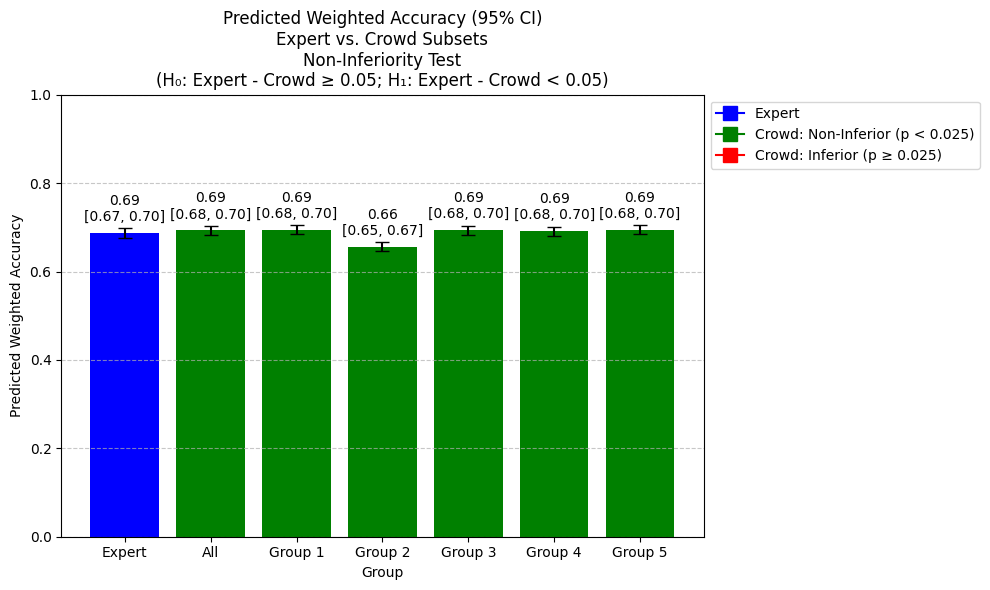

In [ ]:
from scipy.stats import norm
import matplotlib.lines as mlines



def compute_weighted_accuracy(sub_df):
    # For a given problem, select the answer with highest summed combinedaccuracy.
    pred = sub_df.groupby('title')['combinedaccuracy'].sum().idxmax()
    gold = sub_df['goldstandardnew'].iloc[0]
    return int(pred == gold)

# Define non-expert (crowd) records.
non_experts = df[df['experience_level'] != 'Expert']

# ----------------------------
# 2. Define Crowd Subsets
# ----------------------------
subsets = {
    'All': non_experts,
    'Group 1': non_experts[~non_experts['experience_level'].isin(['MD', 'DO'])],
    'Group 2': non_experts[~non_experts['experience_level'].isin(['Medical Student'])],
    'Group 3': non_experts[~non_experts['experience_level'].isin(['NP', 'PA', 'Pharmacist'])],
    'Group 4': non_experts[~non_experts['experience_level'].isin(['NP Student', 'PA Student', 'Pharmacy Student', 'Other Healthcare Student'])],
    'Group 5': non_experts[~non_experts['experience_level'].isin(['Other'])]
}

# ----------------------------
# 3. Prepare Expert Data
# ----------------------------
df_expert = df[df['experience_level'] == 'Expert'].copy()
df_expert['group'] = 'Expert'  # Label all expert records as "Expert"

# ----------------------------
# 4. Fit Mixed-Effects Models for Each Crowd Subset vs. Expert and Extract Predictions
# ----------------------------
comparison_results = {}
noninf_margin = 0.05  # Non-inferiority margin

for key, subset_df in subsets.items():
    # Label crowd subset.
    df_crowd_subset = subset_df.copy()
    df_crowd_subset['group'] = key  # e.g., "All", "Group 1", etc.

    # Combine Expert and current crowd subset.
    combined = pd.concat([df_expert, df_crowd_subset], ignore_index=True)

    # Aggregate by problem.
    agg_data = combined.groupby(['problem_id', 'group']).apply(
        lambda sub: pd.Series({
            'weighted_accuracy': compute_weighted_accuracy(sub),
            'avg_question_count': sub['user_question_count'].mean()
        })
    ).reset_index()

    # Set categorical order with Expert as the reference.
    agg_data['group'] = pd.Categorical(agg_data['group'], categories=['Expert', key], ordered=True)

    # Fit mixed-effects model.
    model = smf.mixedlm("weighted_accuracy ~ group + avg_question_count", agg_data, groups=agg_data["problem_id"])
    res = model.fit()
    print(f"\nComparison for crowd subset: {key}")
    print(res.summary())

    # Extract fixed-effects and fixed covariance.
    fixed_params = res.fe_params
    cov_full = res.cov_params()
    cov_fixed = cov_full.loc[fixed_params.index, fixed_params.index]

    # Global average for avg_question_count.
    global_avg = agg_data['avg_question_count'].mean()

    # Design vectors:
    # For Expert (reference): [1, 0, global_avg]
    # For Crowd subset: [1, 1, global_avg]
    x_expert = np.array([1, 0, global_avg])
    x_crowd = np.array([1, 1, global_avg])

    pred_expert = np.dot(fixed_params, x_expert)
    pred_crowd = np.dot(fixed_params, x_crowd)

    se_expert = np.sqrt(np.dot(x_expert, np.dot(cov_fixed, x_expert)))
    se_crowd = np.sqrt(np.dot(x_crowd, np.dot(cov_fixed, x_crowd)))

    ci_expert = (pred_expert - 1.96 * se_expert, pred_expert + 1.96 * se_expert)
    ci_crowd = (pred_crowd - 1.96 * se_crowd, pred_crowd + 1.96 * se_crowd)

    # Difference: Expert - Crowd (we want this to be below 0.05 for non-inferiority).
    diff = pred_expert - pred_crowd

    # Standard error for the difference equals the standard error of the group coefficient.
    # That is, se_diff = sqrt( Var( group[T.key] ) ).
    se_diff = np.sqrt(cov_fixed.loc[f"group[T.{key}]", f"group[T.{key}]"])

    # Compute non-inferiority test statistic:
    #   T = (noninf_margin - (Expert - Crowd)) / se_diff.
    T_stat = (noninf_margin - diff) / se_diff
    one_sided_p = 1 - norm.cdf(T_stat)

    comparison_results[key] = {
        'predicted_expert': pred_expert,
        'ci_expert': ci_expert,
        'predicted_crowd': pred_crowd,
        'ci_crowd': ci_crowd,
        'noninf_diff': diff,  # Expert minus Crowd difference.
        'se_diff': se_diff,
        'one_sided_p': one_sided_p
    }

# ----------------------------
# 4a. Compute Overall Expert Performance (Expert-only)
# ----------------------------
agg_expert_only = df_expert.groupby('problem_id').apply(
    lambda sub: pd.Series({
        'weighted_accuracy': compute_weighted_accuracy(sub),
        'avg_question_count': sub['user_question_count'].mean()
    })
).reset_index()
overall_expert = agg_expert_only['weighted_accuracy'].mean()
se_expert_overall = agg_expert_only['weighted_accuracy'].std() / np.sqrt(agg_expert_only['problem_id'].nunique())
ci_expert_overall = (overall_expert - 1.96 * se_expert_overall, overall_expert + 1.96 * se_expert_overall)

# ----------------------------
# 5. Assemble Data for Plotting
# ----------------------------
# x-axis: "Expert", "All", "Group 1", "Group 2", "Group 3", "Group 4", "Group 5".
plot_rows = []

# Add Expert (overall) bar.
plot_rows.append({
    "group": "Expert",
    "predicted": overall_expert,
    "ci_lower": ci_expert_overall[0],
    "ci_upper": ci_expert_overall[1],
    "p_value": None,
    "ref": None,
    "se_diff": None
})

# Add each crowd subset using the model-predicted crowd value.
for key, res_dict in comparison_results.items():
    plot_rows.append({
        "group": key,
        "predicted": res_dict['predicted_crowd'],
        "ci_lower": res_dict['ci_crowd'][0],
        "ci_upper": res_dict['ci_crowd'][1],
        "p_value": res_dict['one_sided_p'],  # one-sided non-inferiority p-value.
        "ref": res_dict['predicted_expert'],   # Expert prediction from same model.
        "se_diff": res_dict['se_diff']
    })

plot_df = pd.DataFrame(plot_rows)
print("\nFinal plot data:")
print(plot_df)

# ----------------------------
# 6. Determine Bar Colors for Plotting
# ----------------------------
# Expert bar is blue.
# For each crowd subset, test:
#   Null hypothesis: (Expert - Crowd) ≥ 0.05
#   Alternative: (Expert - Crowd) < 0.05
# If (Expert - Crowd) < 0.05 AND one-sided p-value < 0.025 then assign green (non-inferior), else red.
def assign_color(row):
    if row['group'] == "Expert":
        return "blue"
    else:
        diff = row['ref'] - row['predicted']  # Expert minus Crowd.
        if (diff < noninf_margin) and (row['p_value'] is not None) and (row['p_value'] < 0.025):
            return "green"
        else:
            return "red"

plot_df['color'] = plot_df.apply(assign_color, axis=1)
print("\nPlot data with assigned colors:")
print(plot_df)

# ----------------------------
# 7. Plot the Bar Graph with Legend Outside
# ----------------------------
order = ['Expert', 'All', 'Group 1', 'Group 2', 'Group 3', 'Group 4', 'Group 5']
plot_df['group'] = pd.Categorical(plot_df['group'], categories=order, ordered=True)
plot_df = plot_df.sort_values("group")

plt.figure(figsize=(10, 6))
plt.bar(plot_df['group'], plot_df['predicted'],
        yerr=[plot_df['predicted'] - plot_df['ci_lower'], plot_df['ci_upper'] - plot_df['predicted']],
        capsize=5, color=plot_df['color'])
for idx, row in plot_df.iterrows():
    plt.text(idx, row['predicted'] + 0.02,
             f"{row['predicted']:.2f}\n[{row['ci_lower']:.2f}, {row['ci_upper']:.2f}]",
             ha='center', va='bottom', fontsize=10)
plt.xlabel("Group")
plt.ylabel("Predicted Weighted Accuracy")
plt.title("Predicted Weighted Accuracy (95% CI)\nExpert vs. Crowd Subsets\nNon-Inferiority Test\n(H₀: Expert - Crowd ≥ 0.05; H₁: Expert - Crowd < 0.05)")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Create custom legend handles.
legend_handles = [
    mlines.Line2D([], [], color='blue', marker='s', markersize=10, label='Expert'),
    mlines.Line2D([], [], color='green', marker='s', markersize=10, label='Crowd: Non-Inferior (p < 0.025)'),
    mlines.Line2D([], [], color='red', marker='s', markersize=10, label='Crowd: Inferior (p ≥ 0.025)')
]

plt.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

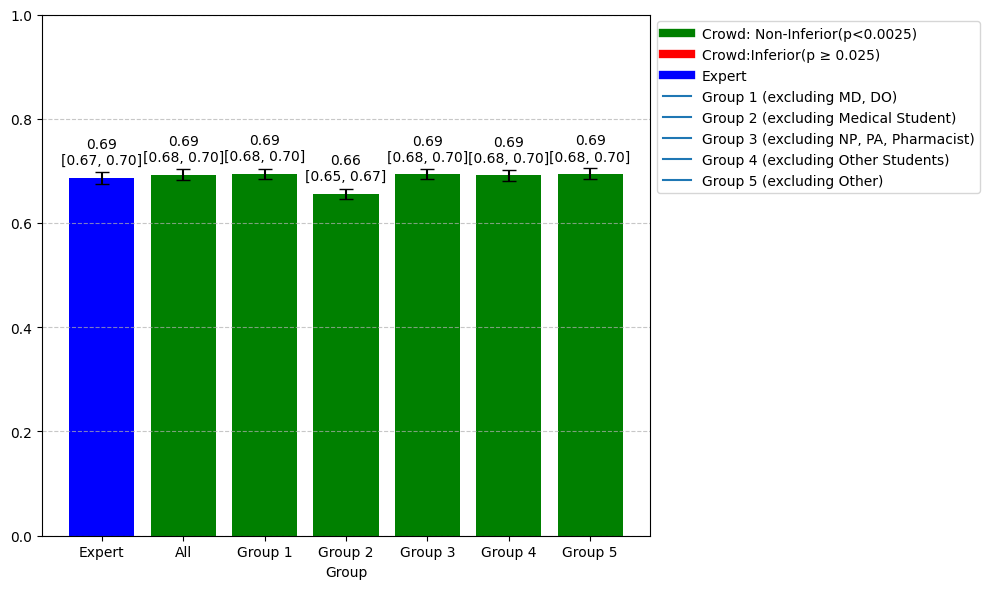

In [ ]:
# ----------------------------
# 7. Plot the Bar Graph with Legend Outside
# ----------------------------
order = ['Expert', 'All', 'Group 1', 'Group 2', 'Group 3', 'Group 4', 'Group 5']
plot_df['group'] = pd.Categorical(plot_df['group'], categories=order, ordered=True)
plot_df = plot_df.sort_values("group")

plt.figure(figsize=(10, 6))
plt.bar(plot_df['group'], plot_df['predicted'],
        yerr=[plot_df['predicted'] - plot_df['ci_lower'], plot_df['ci_upper'] - plot_df['predicted']],
        capsize=5, color=plot_df['color'])
for idx, row in plot_df.iterrows():
    plt.text(idx, row['predicted'] + 0.02,
             f"{row['predicted']:.2f}\n[{row['ci_lower']:.2f}, {row['ci_upper']:.2f}]",
             ha='center', va='bottom', fontsize=10)
plt.xlabel("Group")
plt.ylabel("")
plt.title("")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Create custom legends for bar colors and group descriptions
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='green', lw=6, label='Crowd: Non-Inferior(p<0.0025)'),
    Line2D([0], [0], color='red', lw=6, label='Crowd:Inferior(p ≥ 0.025)'),
    Line2D([0], [0], color='blue', lw=6, label='Expert')
]

# Original legend for groups
group_lines = [
    Line2D([0], [0], label='Group 1 (excluding MD, DO)'),
    Line2D([0], [0], label='Group 2 (excluding Medical Student)'),
    Line2D([0], [0], label='Group 3 (excluding NP, PA, Pharmacist)'),
    Line2D([0], [0], label='Group 4 (excluding Other Students)'),
    Line2D([0], [0], label='Group 5 (excluding Other)')
]

# Combine both legends into one
plt.legend(handles=custom_lines + group_lines, loc='upper left', bbox_to_anchor=(1, 1))


plt.tight_layout()
plt.show()


Processing goldstandardnew pattern: lrda


<ipython-input-43-5e3e2ee26f3a>:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_data = combined.groupby(['problem_id', 'group']).apply(



Model for subset 'All' (Pattern: lrda)
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_accuracy
No. Observations: 1538    Method:             REML             
No. Groups:       886     Scale:              0.1509           
Min. group size:  1       Log-Likelihood:     -975.8233        
Max. group size:  2       Converged:          Yes              
Mean group size:  1.7                                          
---------------------------------------------------------------
                      Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.628    0.037 16.928 0.000  0.555  0.700
group[T.All]          0.098    0.028  3.530 0.000  0.043  0.152
avg_question_count    0.000    0.000  0.093 0.926 -0.000  0.000
Group Var             0.061    0.028                           



<ipython-input-43-5e3e2ee26f3a>:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_data = combined.groupby(['problem_id', 'group']).apply(



Model for subset 'Group 1' (Pattern: lrda)
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_accuracy
No. Observations: 1538    Method:             REML             
No. Groups:       886     Scale:              0.1541           
Min. group size:  1       Log-Likelihood:     -994.9005        
Max. group size:  2       Converged:          Yes              
Mean group size:  1.7                                          
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.638    0.037 17.036 0.000  0.564  0.711
group[T.Group 1]      0.083    0.026  3.243 0.001  0.033  0.134
avg_question_count   -0.000    0.000 -0.253 0.801 -0.000  0.000
Group Var             0.063    0.029                           



...

<ipython-input-43-5e3e2ee26f3a>:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_data = combined.groupby(['problem_id', 'group']).apply(



Model for subset 'Group 4' (Pattern: other)
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_accuracy
No. Observations: 3253    Method:             REML             
No. Groups:       1942    Scale:              0.1332           
Min. group size:  1       Log-Likelihood:     -2175.9740       
Max. group size:  2       Converged:          Yes              
Mean group size:  1.7                                          
---------------------------------------------------------------
                    Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept            0.637    0.024  26.525 0.000  0.590  0.685
group[T.Group 4]    -0.164    0.016 -10.470 0.000 -0.195 -0.133
avg_question_count  -0.000    0.000  -0.161 0.872 -0.000  0.000
Group Var            0.109    0.026                            



<ipython-input-43-5e3e2ee26f3a>:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_data = combined.groupby(['problem_id', 'group']).apply(



Model for subset 'Group 5' (Pattern: other)
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_accuracy
No. Observations: 3253    Method:             REML             
No. Groups:       1942    Scale:              0.1311           
Min. group size:  1       Log-Likelihood:     -2170.6435       
Max. group size:  2       Converged:          Yes              
Mean group size:  1.7                                          
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.642    0.024 26.656 0.000  0.594  0.689
group[T.Group 5]     -0.154    0.016 -9.762 0.000 -0.185 -0.123
avg_question_count   -0.000    0.000 -0.397 0.691 -0.000  0.000
Group Var             0.111    0.027                           



<ipython-input-43-5e3e2ee26f3a>:114: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_expert_only = df_expert.groupby('problem_id').apply(


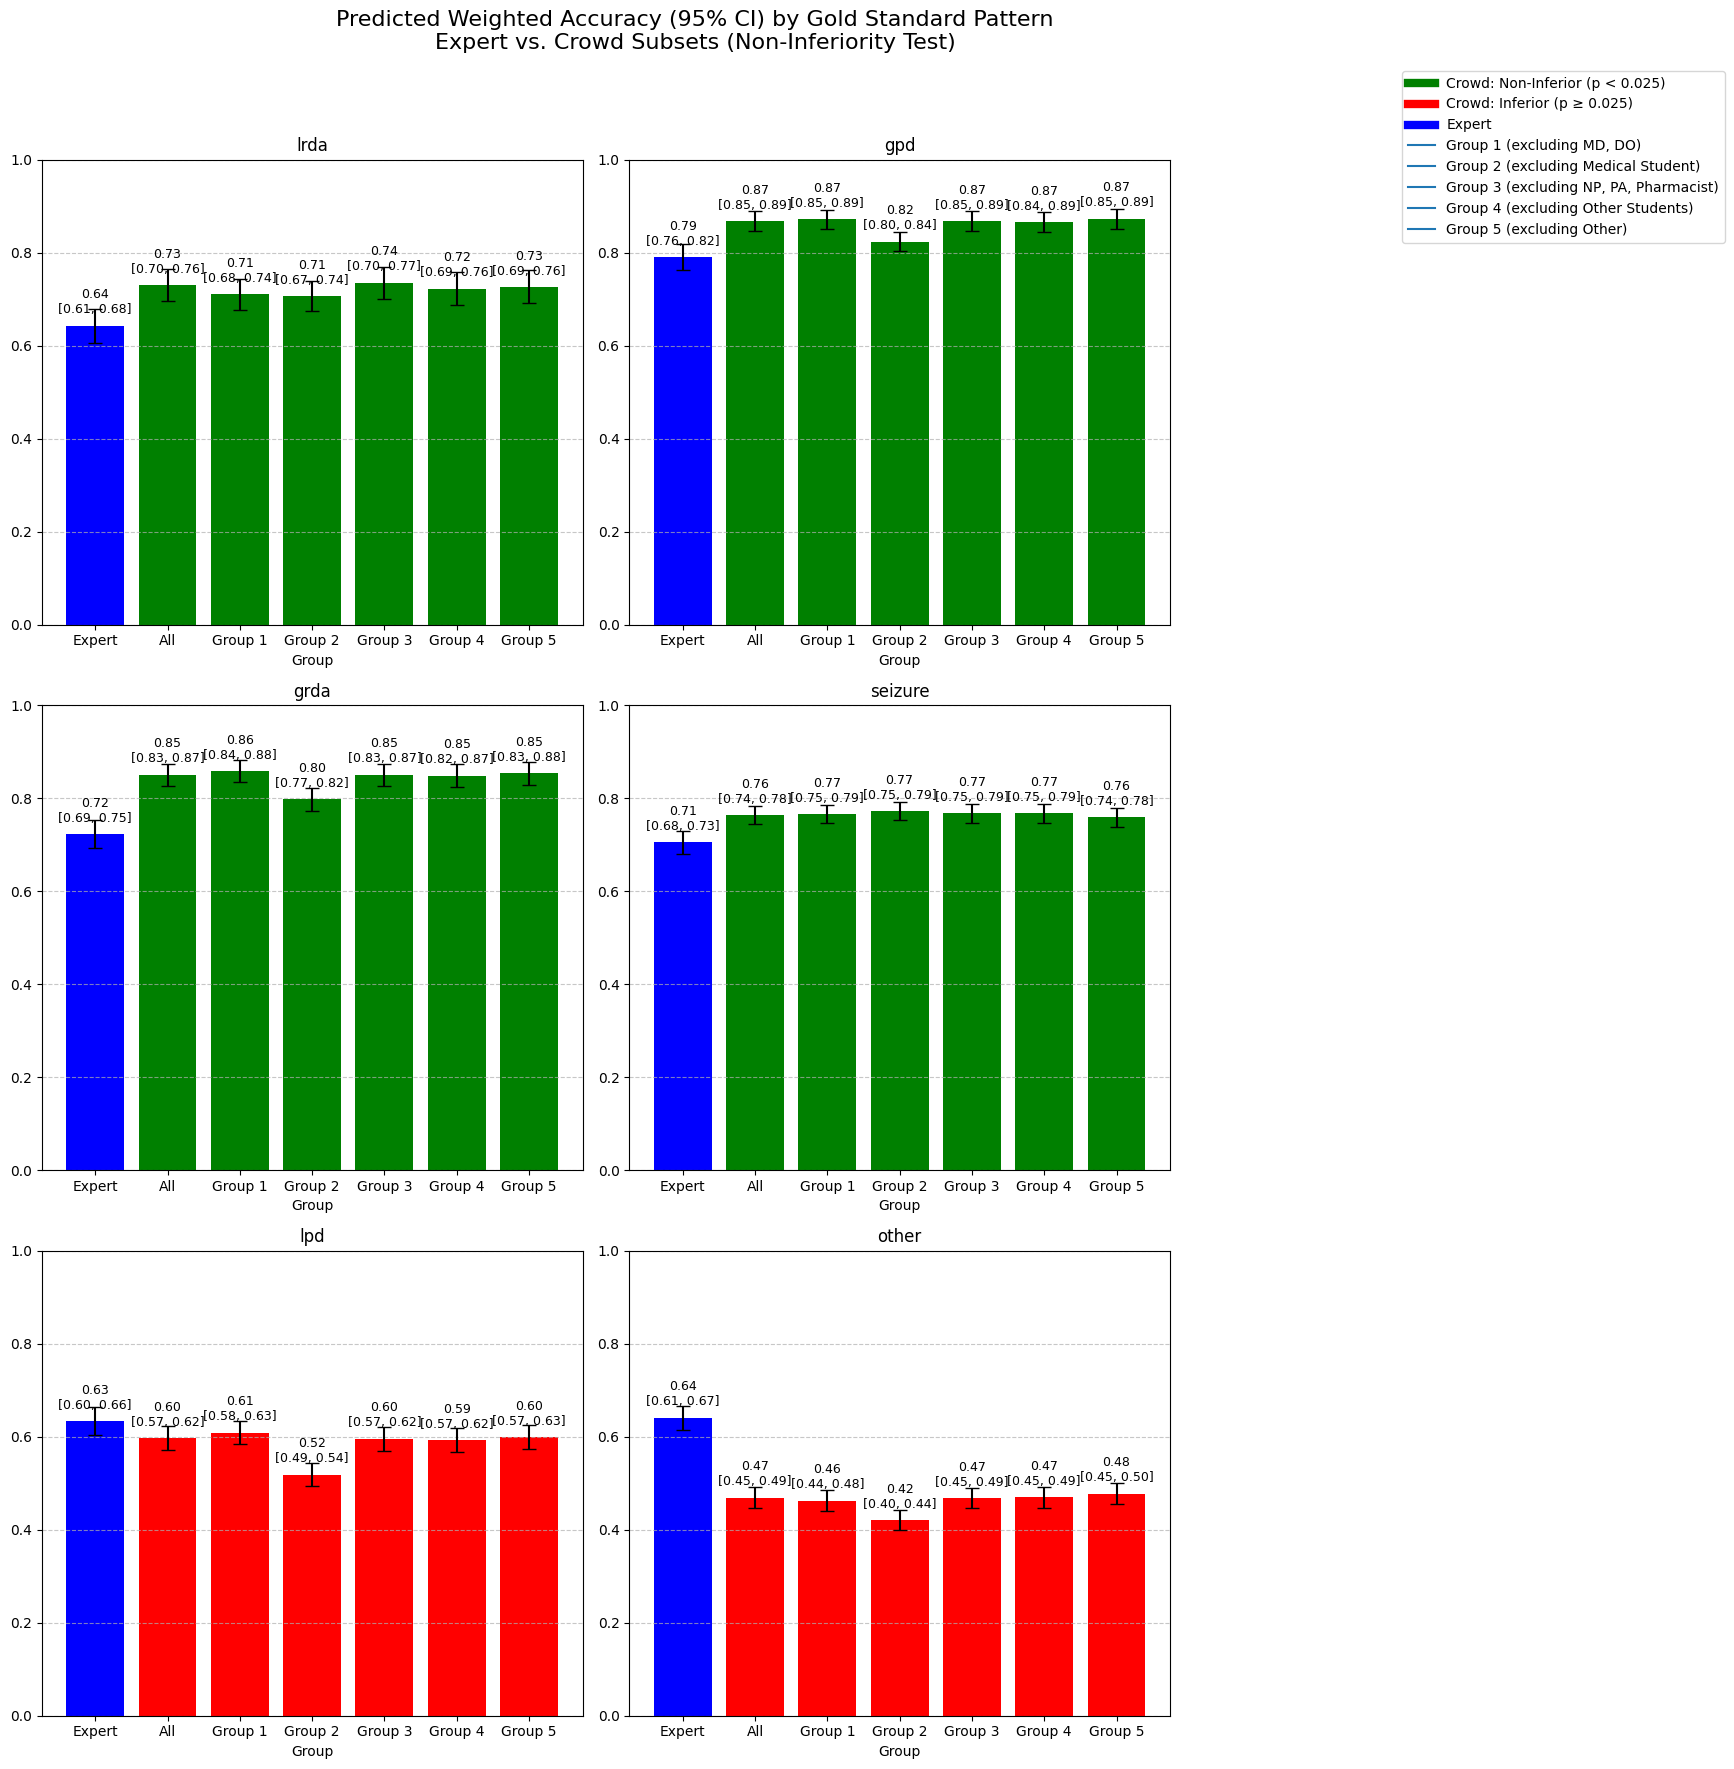

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
from matplotlib.lines import Line2D

# ----------------------------
# Data Preparation (Assumes df is preloaded with required columns)
# ----------------------------
df['correct'] = (df['title'] == df['goldstandardnew']).astype(int)

def compute_weighted_accuracy(sub_df):
    # For a given problem, select the answer with the highest summed combinedaccuracy.
    pred = sub_df.groupby('title')['combinedaccuracy'].sum().idxmax()
    gold = sub_df['goldstandardnew'].iloc[0]
    return int(pred == gold)

# ----------------------------
# Define the Function to Plot a Bar Graph for a Given Goldstandardnew Pattern
# ----------------------------
def plot_bar_for_pattern(ax, pattern, df):
    # Filter the data for the specified goldstandardnew pattern.
    pattern_df = df[df['goldstandardnew'] == pattern].copy()
    print(f"\nProcessing goldstandardnew pattern: {pattern}")

    # Separate Expert and non-Expert records.
    df_expert = pattern_df[pattern_df['experience_level'] == 'Expert'].copy()
    df_expert['group'] = 'Expert'
    non_experts = pattern_df[pattern_df['experience_level'] != 'Expert']

    # Define crowd subsets.
    subsets = {
        'All': non_experts,
        'Group 1': non_experts[~non_experts['experience_level'].isin(['MD', 'DO'])],
        'Group 2': non_experts[~non_experts['experience_level'].isin(['Medical Student'])],
        'Group 3': non_experts[~non_experts['experience_level'].isin(['NP', 'PA', 'Pharmacist'])],
        'Group 4': non_experts[~non_experts['experience_level'].isin(['NP Student', 'PA Student', 'Pharmacy Student', 'Other Healthcare Student'])],
        'Group 5': non_experts[~non_experts['experience_level'].isin(['Other'])]
    }

    comparison_results = {}
    noninf_margin = 0.05  # Non-inferiority margin

    # Loop through each crowd subset.
    for key, subset_df in subsets.items():
        df_crowd_subset = subset_df.copy()
        df_crowd_subset['group'] = key  # Label this subset

        # Combine Expert and the crowd subset.
        combined = pd.concat([df_expert, df_crowd_subset], ignore_index=True)

        # Aggregate performance by problem.
        agg_data = combined.groupby(['problem_id', 'group']).apply(
            lambda sub: pd.Series({
                'weighted_accuracy': compute_weighted_accuracy(sub),
                'avg_question_count': sub['user_question_count'].mean()
            })
        ).reset_index()

        # Set categorical order with Expert as reference.
        agg_data['group'] = pd.Categorical(agg_data['group'], categories=['Expert', key], ordered=True)

        # Fit the mixed-effects model.
        model = smf.mixedlm("weighted_accuracy ~ group + avg_question_count", agg_data, groups=agg_data["problem_id"])
        res = model.fit()
        print(f"\nModel for subset '{key}' (Pattern: {pattern})")
        print(res.summary())

        # Extract fixed-effects estimates and fixed covariance.
        fixed_params = res.fe_params
        cov_full = res.cov_params()
        cov_fixed = cov_full.loc[fixed_params.index, fixed_params.index]

        # Compute the global average of avg_question_count in this aggregation.
        global_avg = agg_data['avg_question_count'].mean()

        # Design vectors.
        # For Expert (reference): [1, 0, global_avg]
        # For Crowd: [1, 1, global_avg]
        x_expert = np.array([1, 0, global_avg])
        x_crowd = np.array([1, 1, global_avg])

        pred_expert = np.dot(fixed_params, x_expert)
        pred_crowd = np.dot(fixed_params, x_crowd)

        se_expert = np.sqrt(np.dot(x_expert, np.dot(cov_fixed, x_expert)))
        se_crowd = np.sqrt(np.dot(x_crowd, np.dot(cov_fixed, x_crowd)))

        ci_expert = (pred_expert - 1.96 * se_expert, pred_expert + 1.96 * se_expert)
        ci_crowd = (pred_crowd - 1.96 * se_crowd, pred_crowd + 1.96 * se_crowd)

        # Compute difference: Expert - Crowd.
        diff = pred_expert - pred_crowd
        # Standard error for the difference equals the standard error of the group parameter.
        se_diff = np.sqrt(cov_fixed.loc[f"group[T.{key}]", f"group[T.{key}]"])

        # Non-inferiority test: H₀: (Expert - Crowd) ≥ 0.05 vs. H₁: (Expert - Crowd) < 0.05.
        T_stat = (noninf_margin - diff) / se_diff
        one_sided_p = 1 - norm.cdf(T_stat)

        comparison_results[key] = {
            'predicted_expert': pred_expert,
            'ci_expert': ci_expert,
            'predicted_crowd': pred_crowd,
            'ci_crowd': ci_crowd,
            'noninf_diff': diff,    # Expert - Crowd difference.
            'se_diff': se_diff,
            'one_sided_p': one_sided_p
        }

    # Compute overall Expert performance (from Expert-only data).
    agg_expert_only = df_expert.groupby('problem_id').apply(
        lambda sub: pd.Series({
            'weighted_accuracy': compute_weighted_accuracy(sub),
            'avg_question_count': sub['user_question_count'].mean()
        })
    ).reset_index()
    overall_expert = agg_expert_only['weighted_accuracy'].mean()
    se_expert_overall = agg_expert_only['weighted_accuracy'].std() / np.sqrt(agg_expert_only['problem_id'].nunique())
    ci_expert_overall = (overall_expert - 1.96 * se_expert_overall, overall_expert + 1.96 * se_expert_overall)

    # ----------------------------
    # Assemble Plot Data for this Pattern.
    # ----------------------------
    plot_rows = []
    plot_rows.append({
        "group": "Expert",
        "predicted": overall_expert,
        "ci_lower": ci_expert_overall[0],
        "ci_upper": ci_expert_overall[1],
        "p_value": None,
        "ref": None,
        "se_diff": None
    })
    for key, res_dict in comparison_results.items():
        plot_rows.append({
            "group": key,
            "predicted": res_dict['predicted_crowd'],
            "ci_lower": res_dict['ci_crowd'][0],
            "ci_upper": res_dict['ci_crowd'][1],
            "p_value": res_dict['one_sided_p'],
            "ref": res_dict['predicted_expert'],
            "se_diff": res_dict['se_diff']
        })
    plot_df = pd.DataFrame(plot_rows)

    # Determine bar colors.
    def assign_color(row):
        if row['group'] == "Expert":
            return "blue"
        else:
            # Compute difference: Expert (from same model) minus Crowd.
            diff_local = row['ref'] - row['predicted']
            if (diff_local < noninf_margin) and (row['p_value'] is not None) and (row['p_value'] < 0.025):
                return "green"
            else:
                return "red"
    plot_df['color'] = plot_df.apply(assign_color, axis=1)

    # Plot the bar graph on the provided axis.
    order = ['Expert', 'All', 'Group 1', 'Group 2', 'Group 3', 'Group 4', 'Group 5']
    plot_df['group'] = pd.Categorical(plot_df['group'], categories=order, ordered=True)
    plot_df = plot_df.sort_values("group")

    ax.bar(plot_df['group'], plot_df['predicted'],
           yerr=[plot_df['predicted'] - plot_df['ci_lower'], plot_df['ci_upper'] - plot_df['predicted']],
           capsize=5, color=plot_df['color'])
    for idx, row in plot_df.iterrows():
        ax.text(idx, row['predicted'] + 0.02,
                 f"{row['predicted']:.2f}\n[{row['ci_lower']:.2f}, {row['ci_upper']:.2f}]",
                 ha='center', va='bottom', fontsize=9)
    ax.set_xlabel("Group")
    ax.set_ylabel("")
    ax.set_ylim(0, 1)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_title(f"{pattern}")

# ----------------------------
# 5. Plot All Graphs in One Figure (3 Rows x 2 Columns)
# ----------------------------
# Get unique goldstandardnew patterns.
unique_patterns = df['goldstandardnew'].unique()
# Create a figure with 3 rows and 2 columns.
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

# Loop over unique patterns and corresponding axis.
for ax, pattern in zip(axes.flat, unique_patterns):
    plot_bar_for_pattern(ax, pattern, df)

# Create custom legend handles.
custom_lines = [
    Line2D([0], [0], color='green', lw=6, label='Crowd: Non-Inferior (p < 0.025)'),
    Line2D([0], [0], color='red', lw=6, label='Crowd: Inferior (p ≥ 0.025)'),
    Line2D([0], [0], color='blue', lw=6, label='Expert')
]

group_lines = [
    Line2D([0], [0], label='Group 1 (excluding MD, DO)'),
    Line2D([0], [0], label='Group 2 (excluding Medical Student)'),
    Line2D([0], [0], label='Group 3 (excluding NP, PA, Pharmacist)'),
    Line2D([0], [0], label='Group 4 (excluding Other Students)'),
    Line2D([0], [0], label='Group 5 (excluding Other)')
]

# Combine both legends.
fig.legend(handles=custom_lines + group_lines, loc='upper left', bbox_to_anchor=(1, 0.95))
fig.suptitle("Predicted Weighted Accuracy (95% CI) by Gold Standard Pattern\nExpert vs. Crowd Subsets (Non-Inferiority Test)", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()


Top 20% combinedaccuracy threshold: 0.7272727272727274


<ipython-input-17-d4e580a7c233>:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  overall_NW_summary = agg_overall_NW.groupby('group')['predicted_accuracy'].agg(['mean','std','count']).reset_index()
<ipython-input-17-d4e580a7c233>:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pattern_NW_summary = agg_pattern_NW.groupby(['pattern','group'])['predicted_accuracy'].agg(['mean','std','count']).reset_index()


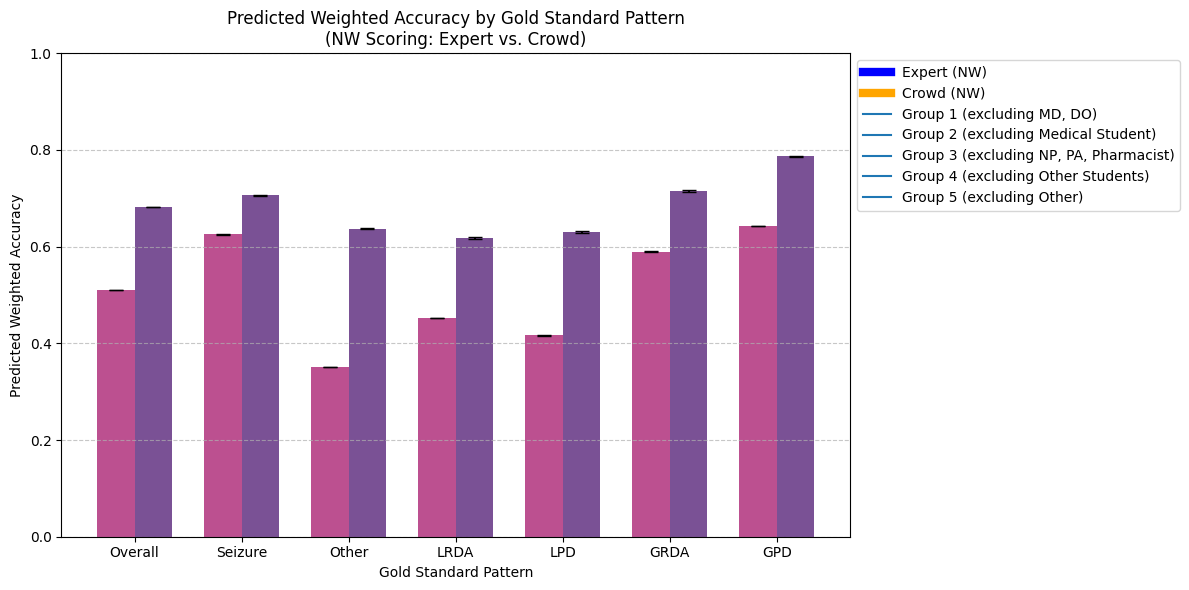

In [17]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.lines as mlines

# ----------------------------
# 1. Filter the DataFrame
# ----------------------------
# Keep all Expert rows and only non-Expert rows with combinedaccuracy > 0.68
#filtered_crowd = df[(df['experience_level'] == 'Expert') | ((df['experience_level'] != 'Expert') & (df['combinedaccuracy'] > 0.68))]
#df = filtered_crowd.copy()
# Separate out non-expert rows.
non_experts = df[df['experience_level'] != 'Expert']

# Compute the threshold for the top 20% performers.
threshold = non_experts['combinedaccuracy'].quantile(0.2)
print("Top 80% combinedaccuracy threshold:", threshold)

# Filter the DataFrame: keep all Expert rows or non-Expert rows with combinedaccuracy at or above the threshold.
filtered_crowd = df[(df['experience_level'] == 'Expert') | ((df['experience_level'] != 'Expert') & (df['combinedaccuracy'] >= threshold))]

# Create a new DataFrame with the filtered rows.
df = filtered_crowd.copy()

# For this analysis, we assume that df contains at least these columns:
# 'user_id', 'title', 'goldstandardnew', 'experience_level', 'problem_id',
# 'combinedaccuracy', 'user_question_count', and that a binary column 'correct'
# can be computed as (title == goldstandardnew).

df['correct'] = (df['title'] == df['goldstandardnew']).astype(int)
df['group'] = df['experience_level'].apply(lambda x: 'Expert' if x == 'Expert' else 'Crowd')
df['user_question_count'] = df.groupby('user_id')['problem_id'].transform('nunique')

# ----------------------------
# 2. Model 1: Overall, Non-Weighted
# ----------------------------
# It is assumed that the column 'group' already indicates Expert vs. Crowd.
# For this example, we create group based on experience_level:
df['group'] = np.where(df['experience_level'] == 'Expert', 'Expert', 'Crowd')

agg_overall_NW = df.groupby(['problem_id', 'group']).agg({
    'correct': ['mean', 'count'],
    'user_question_count': 'mean'
}).reset_index()
agg_overall_NW.columns = ['problem_id', 'group', 'accuracy', 'n', 'avg_question_count']
agg_overall_NW['group'] = agg_overall_NW['group'].astype('category')

model_overall_NW = smf.mixedlm("accuracy ~ group + avg_question_count", agg_overall_NW,
                               groups=agg_overall_NW["problem_id"])
result_overall_NW = model_overall_NW.fit()

# Compute predicted_accuracy from overall model.
agg_overall_NW['predicted_accuracy'] = result_overall_NW.predict(agg_overall_NW)
overall_NW_summary = agg_overall_NW.groupby('group')['predicted_accuracy'].agg(['mean','std','count']).reset_index()
overall_NW_summary['se'] = overall_NW_summary['std'] / np.sqrt(overall_NW_summary['count'])
overall_NW_summary['ci'] = 1.96 * overall_NW_summary['se']
overall_NW_summary['pattern'] = 'Overall'
overall_NW_summary['scoring'] = 'NW'

# ----------------------------
# 3. Model 2: By-Pattern, Non-Weighted
# ----------------------------
# Here, we let the goldstandardnew column be our pattern.
agg_pattern_NW = df.groupby(['problem_id', 'group', 'goldstandardnew'], observed=True).agg({
    'correct': 'mean',
    'user_question_count': 'mean'
}).reset_index()
agg_pattern_NW.rename(columns={'correct': 'accuracy',
                               'user_question_count': 'avg_question_count',
                               'goldstandardnew': 'pattern'}, inplace=True)
agg_pattern_NW['group'] = agg_pattern_NW['group'].astype('category')
agg_pattern_NW['pattern'] = agg_pattern_NW['pattern'].astype('category')

model_pattern_NW = smf.mixedlm("accuracy ~ group * pattern + avg_question_count", agg_pattern_NW,
                               groups=agg_pattern_NW["problem_id"])
result_pattern_NW = model_pattern_NW.fit()

# Compute predicted_accuracy from pattern model.
agg_pattern_NW['predicted_accuracy'] = result_pattern_NW.predict(agg_pattern_NW)
pattern_NW_summary = agg_pattern_NW.groupby(['pattern','group'])['predicted_accuracy'].agg(['mean','std','count']).reset_index()
pattern_NW_summary['se'] = pattern_NW_summary['std'] / np.sqrt(pattern_NW_summary['count'])
pattern_NW_summary['ci'] = 1.96 * pattern_NW_summary['se']
pattern_NW_summary['scoring'] = 'NW'

# ----------------------------
# 4. Combine Summaries
# ----------------------------
# For the overall model, recode group "Expert" or "Crowd" into pattern "Overall" (here we take overall expert and overall crowd).
# Since we want to plot by pattern on the x-axis, we keep overall_NW_summary with pattern "Overall"
bar_df = pd.concat([overall_NW_summary, pattern_NW_summary], ignore_index=True)

# Order: put Overall first, then the other patterns alphabetically.
cat_order = ['Overall'] + sorted([p for p in bar_df['pattern'].unique() if p != 'Overall'])
bar_df['pattern'] = pd.Categorical(bar_df['pattern'], categories=cat_order, ordered=True)
bar_df.sort_values('pattern', inplace=True)

# Standardize group label (we already have "Expert" and "Crowd").
bar_df['group_std'] = bar_df['group']

# ----------------------------
# 5. Rename Patterns and Order Categories
# ----------------------------
# Assuming the pattern names may be lower-case, we apply a rename dictionary.
rename_dict = {
    'gpd': 'GPD',
    'seizure': 'Seizure',
    'other': 'Other',
    'lrda': 'LRDA',
    'lpd': 'LPD',
    'grda': 'GRDA',
    'Overall': 'Overall'
}
bar_df['pattern'] = bar_df['pattern'].apply(lambda x: rename_dict.get(x, x))

# Define final order of patterns for plotting.
final_cat_order = ['Overall', 'Seizure', 'Other', 'LRDA', 'LPD', 'GRDA', 'GPD']
bar_df['pattern'] = pd.Categorical(bar_df['pattern'], categories=final_cat_order, ordered=True)
bar_df.sort_values('pattern', inplace=True)

# ----------------------------
# 6. Plot the Group Bar Graph: x-axis = Pattern, bars grouped by Expert vs. Crowd
# ----------------------------
# Colors for groups:
colors = {
    'Expert (NW)': '#7a5195',   # Light blue (for Expert)
    'Crowd (NW)': '#bc5090'     # Muted orange (for Crowd)
}

# Create a grouped bar chart.
# We'll plot one bar for each group within each pattern.
patterns = bar_df['pattern'].unique()
groups = bar_df['group_std'].unique()
n_patterns = len(patterns)
n_groups = len(groups)

# Define positions for grouped bars.
bar_width = 0.35
x = np.arange(n_patterns)  # x positions for patterns.

fig, ax = plt.subplots(figsize=(12, 6))

# For each group, plot its bar for each pattern.
for i, grp in enumerate(groups):
    grp_data = bar_df[bar_df['group_std'] == grp]
    # Get predicted accuracy in the order of the patterns:
    y = grp_data.sort_values('pattern')['mean'].values
    # Get error bars:
    err = grp_data.sort_values('pattern')['ci'].values
    # Adjust x positions for group bars.
    xpos = x - bar_width/2 + i*(bar_width)
    # Set the color based on group.
    color_val = colors['Expert (NW)'] if grp == 'Expert' else colors['Crowd (NW)']
    ax.bar(xpos, y, width=bar_width, yerr=err, capsize=5, color=color_val, label=grp)

# Set x-axis tick labels.
ax.set_xticks(x)
ax.set_xticklabels(final_cat_order)
ax.set_ylabel("Predicted Weighted Accuracy")
ax.set_xlabel("Gold Standard Pattern")
ax.set_title("Predicted Weighted Accuracy by Gold Standard Pattern\n(NW Scoring: Expert vs. Crowd)")
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Create custom legend combining group colors and group descriptions.
custom_lines = [
    Line2D([0], [0], color='blue', lw=6, label='Expert (NW)'),
    Line2D([0], [0], color='orange', lw=6, label='Crowd (NW)')
]
group_lines = [
    Line2D([0], [0], label='Group 1 (excluding MD, DO)'),
    Line2D([0], [0], label='Group 2 (excluding Medical Student)'),
    Line2D([0], [0], label='Group 3 (excluding NP, PA, Pharmacist)'),
    Line2D([0], [0], label='Group 4 (excluding Other Students)'),
    Line2D([0], [0], label='Group 5 (excluding Other)')
]
ax.legend(handles=custom_lines + group_lines, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()


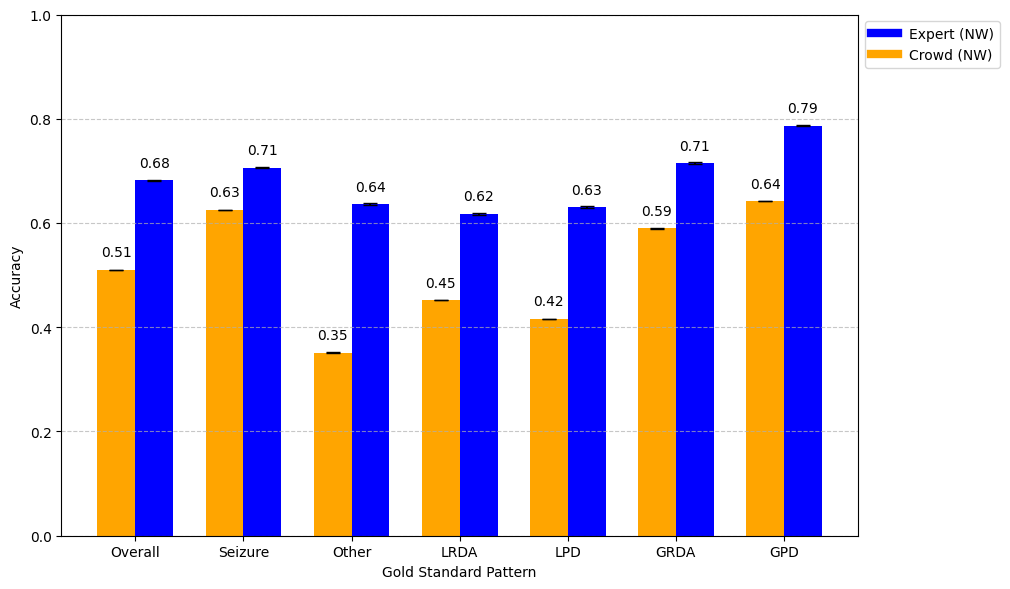

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Define the colors: expert blue and crowd orange.
colors = {
    'Expert (NW)': 'blue',
    'Crowd (NW)': 'orange'
}

# Assume final_cat_order is the list of patterns in the desired order.
final_cat_order = ['Overall', 'Seizure', 'Other', 'LRDA', 'LPD', 'GRDA', 'GPD']

# Ensure the DataFrame has a categorical pattern column.
bar_df['pattern'] = pd.Categorical(bar_df['pattern'], categories=final_cat_order, ordered=True)
bar_df.sort_values('pattern', inplace=True)

# We assume that bar_df has a standardized group column "group_std" with values "Expert" or "Crowd".
# And that the predicted accuracy is stored in the column "mean" and the margin error in "ci".
# (For example, if your summary has "predicted_accuracy" instead, rename it accordingly.)

# Define the groups (we expect two: Expert and Crowd).
groups = bar_df['group_std'].unique()
n_patterns = len(bar_df['pattern'].unique())
bar_width = 0.35
# Create x positions for each pattern.
x = np.arange(n_patterns)

fig, ax = plt.subplots(figsize=(12, 6))

# For each group (Expert and Crowd), plot its bar for each pattern.
for i, grp in enumerate(groups):
    grp_data = bar_df[bar_df['group_std'] == grp]
    # Ensure data are ordered by the pattern.
    grp_data = grp_data.sort_values('pattern')
    # Use column 'mean' for predicted accuracy and 'ci' for error (if your summary uses different names, change here).
    y = grp_data['mean'].values
    err = grp_data['ci'].values
    # Adjust x positions: for two groups, shift one left and one right.
    xpos = x - bar_width/2 + i*bar_width
    # Set the color based on group.
    color_val = colors['Expert (NW)'] if grp == 'Expert' else colors['Crowd (NW)']
    ax.bar(xpos, y, width=bar_width, yerr=err, capsize=5, color=color_val, label=grp)
    # Annotate each bar with the predicted accuracy, placed right above the top.
    for j, val in enumerate(y):
        ax.text(xpos[j], val + 0.02, f"{val:.2f}",
                ha='center', va='bottom', fontsize=10)

# Set the x-axis tick labels as the final_cat_order.
ax.set_xticks(x)
ax.set_xticklabels(final_cat_order)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Gold Standard Pattern")
ax.set_title("")
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Create a legend with only the two group entries.
custom_lines = [
    Line2D([0], [0], color=colors['Expert (NW)'], lw=6, label='Expert (NW)'),
    Line2D([0], [0], color=colors['Crowd (NW)'], lw=6, label='Crowd (NW)')
]
ax.legend(handles=custom_lines, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()
